# 00 · The whole project in one notebook

**The question.** You have many short pieces of data -- *windows*: one day of
traffic, six hours of a wind turbine, one heartbeat. Each window was produced
by one of a few hidden **rules** (closed-form laws, e.g. $y = x^2 + x$). Nobody
tells you which rule produced which window. Can you recover **both** the rules
**and** which window came from which rule?

This notebook is the whole project from the beginning, written for a reader
who is not a specialist:

| part | what you get |
|---|---|
| 1 · Motivation | why "cluster by the law" and not by how the data look |
| 2 · The method | the model, the **objective function**, the **optimisation**, the pipeline |
| 3 · A worked example | the method run live, step by step, on simulated data |
| 4 · What works | the main results, as plots |
| 5 · Real data, live | bike-sharing days on a calendar, coloured by the law found |
| 6 · What did not work | two failures, shown, and the list of the others |
| 7 · Every task in one picture | the fifteen missions + the symbolic-regression baseline |

**How to run.** Top to bottom, about two minutes. Parts 3, 5 and 6 compute
live; the other plots read the committed results in `results/` (produced by
`python -m experiments all`), so nothing here needs a long run. Notebooks
01-08 go deeper into each part.

In [1]:
import sys, pathlib
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from lrdsr import viz
viz.style()
pd.set_option("display.precision", 4)
RES = ROOT / "results"

---
# 1 · Motivation: similar-looking is not the same mechanism

The usual recipe is *cluster the windows, then describe each cluster*: compute
a few statistics of each window (mean, spread, trend, ...), group windows that
are close, then fit a model per group. That recipe groups windows that **look**
alike. But two windows can look very different and still come from the same
rule -- because they saw different inputs -- and two windows can look alike
and come from different rules.

Below: four windows. Which ones belong together?

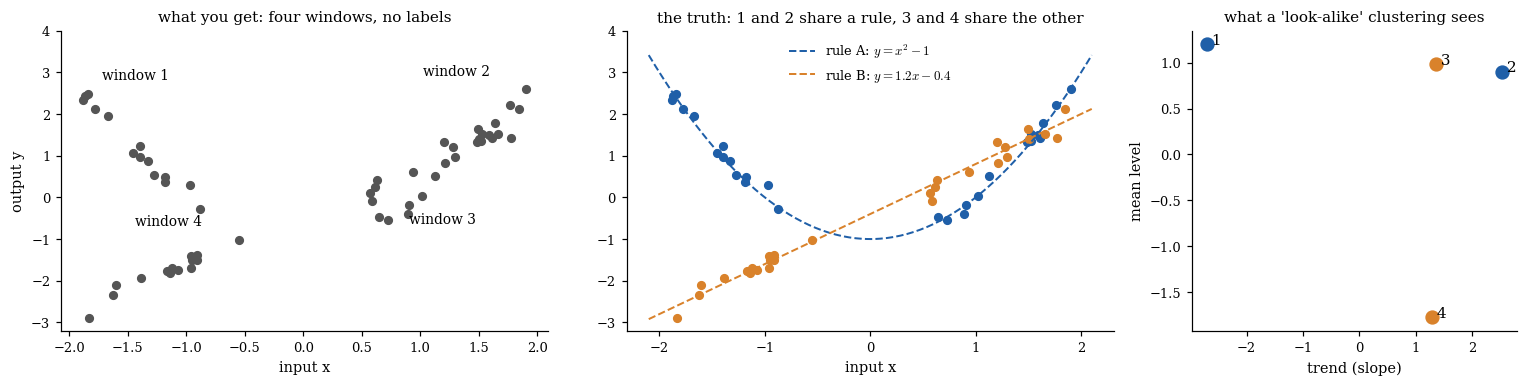

In [2]:
rng = np.random.default_rng(3)
def law_A(x): return x**2 - 1          # a parabola
def law_B(x): return 1.2 * x - 0.4     # a straight line
wins = [("A", law_A, (-2.0, -0.6)), ("A", law_A, (0.6, 2.0)),
        ("B", law_B, (0.3, 1.9)),   ("B", law_B, (-1.9, -0.5))]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), gridspec_kw={"width_ratios": [1.5, 1.5, 1]})
xg = np.linspace(-2.1, 2.1, 200)
stats = []
for i, (tag, f, (lo, hi)) in enumerate(wins):
    x = np.sort(rng.uniform(lo, hi, 14)); y = f(x) + rng.normal(0, 0.18, x.size)
    ax[0].plot(x, y, "o", ms=5, color="#555555")
    ty = y.min() - 0.55 if i == 2 else y.max() + 0.35
    ax[0].annotate(f"window {i + 1}", (x.mean(), ty), ha="center", fontsize=9)
    c = viz.regime_color(0 if tag == "A" else 1)
    ax[1].plot(x, y, "o", ms=5, color=c)
    stats.append((np.polyfit(x, y, 1)[0], y.mean(), tag, i + 1))
ax[0].set(title="what you get: four windows, no labels", xlabel="input x", ylabel="output y", ylim=(-3.2, 4))
ax[1].plot(xg, law_A(xg), "--", color=viz.regime_color(0), lw=1.3, label="rule A: $y = x^2 - 1$")
ax[1].plot(xg, law_B(xg), "--", color=viz.regime_color(1), lw=1.3, label="rule B: $y = 1.2x - 0.4$")
ax[1].set(title="the truth: 1 and 2 share a rule, 3 and 4 share the other", xlabel="input x", ylim=(-3.2, 4))
ax[1].legend(loc="upper center")
for s, m, tag, i in stats:
    ax[2].scatter(s, m, s=70, color=viz.regime_color(0 if tag == "A" else 1))
    ax[2].annotate(f" {i}", (s, m), fontsize=10)
ax[2].set(title="what a 'look-alike' clustering sees", xlabel="trend (slope)", ylabel="mean level")
fig.tight_layout()

In the right panel (the statistics a look-alike clustering would use),
window 2 sits next to window 3 -- a different rule -- while window 1 is as far
from its true partner 2 as anything on the plot. The only thing the two windows of rule A have in common is **the
equation that produced them**. So this project makes the equation the cluster
identity:

> two windows are similar when **the same law** produced them, however
> different they look.

Where this matters in practice: the same machine seen at different operating
points (a wind turbine at low vs. high wind), days observed at different hours
(a sensor that dropped out), any setting where the *inputs* of a window vary.
The output is also more useful than a cluster number: it is a **readable
equation per group**.

---
# 2 · The method (LR-DSR: *latent-regime symbolic regression*)

The idea in one picture, and the vocabulary laws are built from
(`docs/algorithm/`; notebook `09_algorithm_tutorial` builds every block by hand):

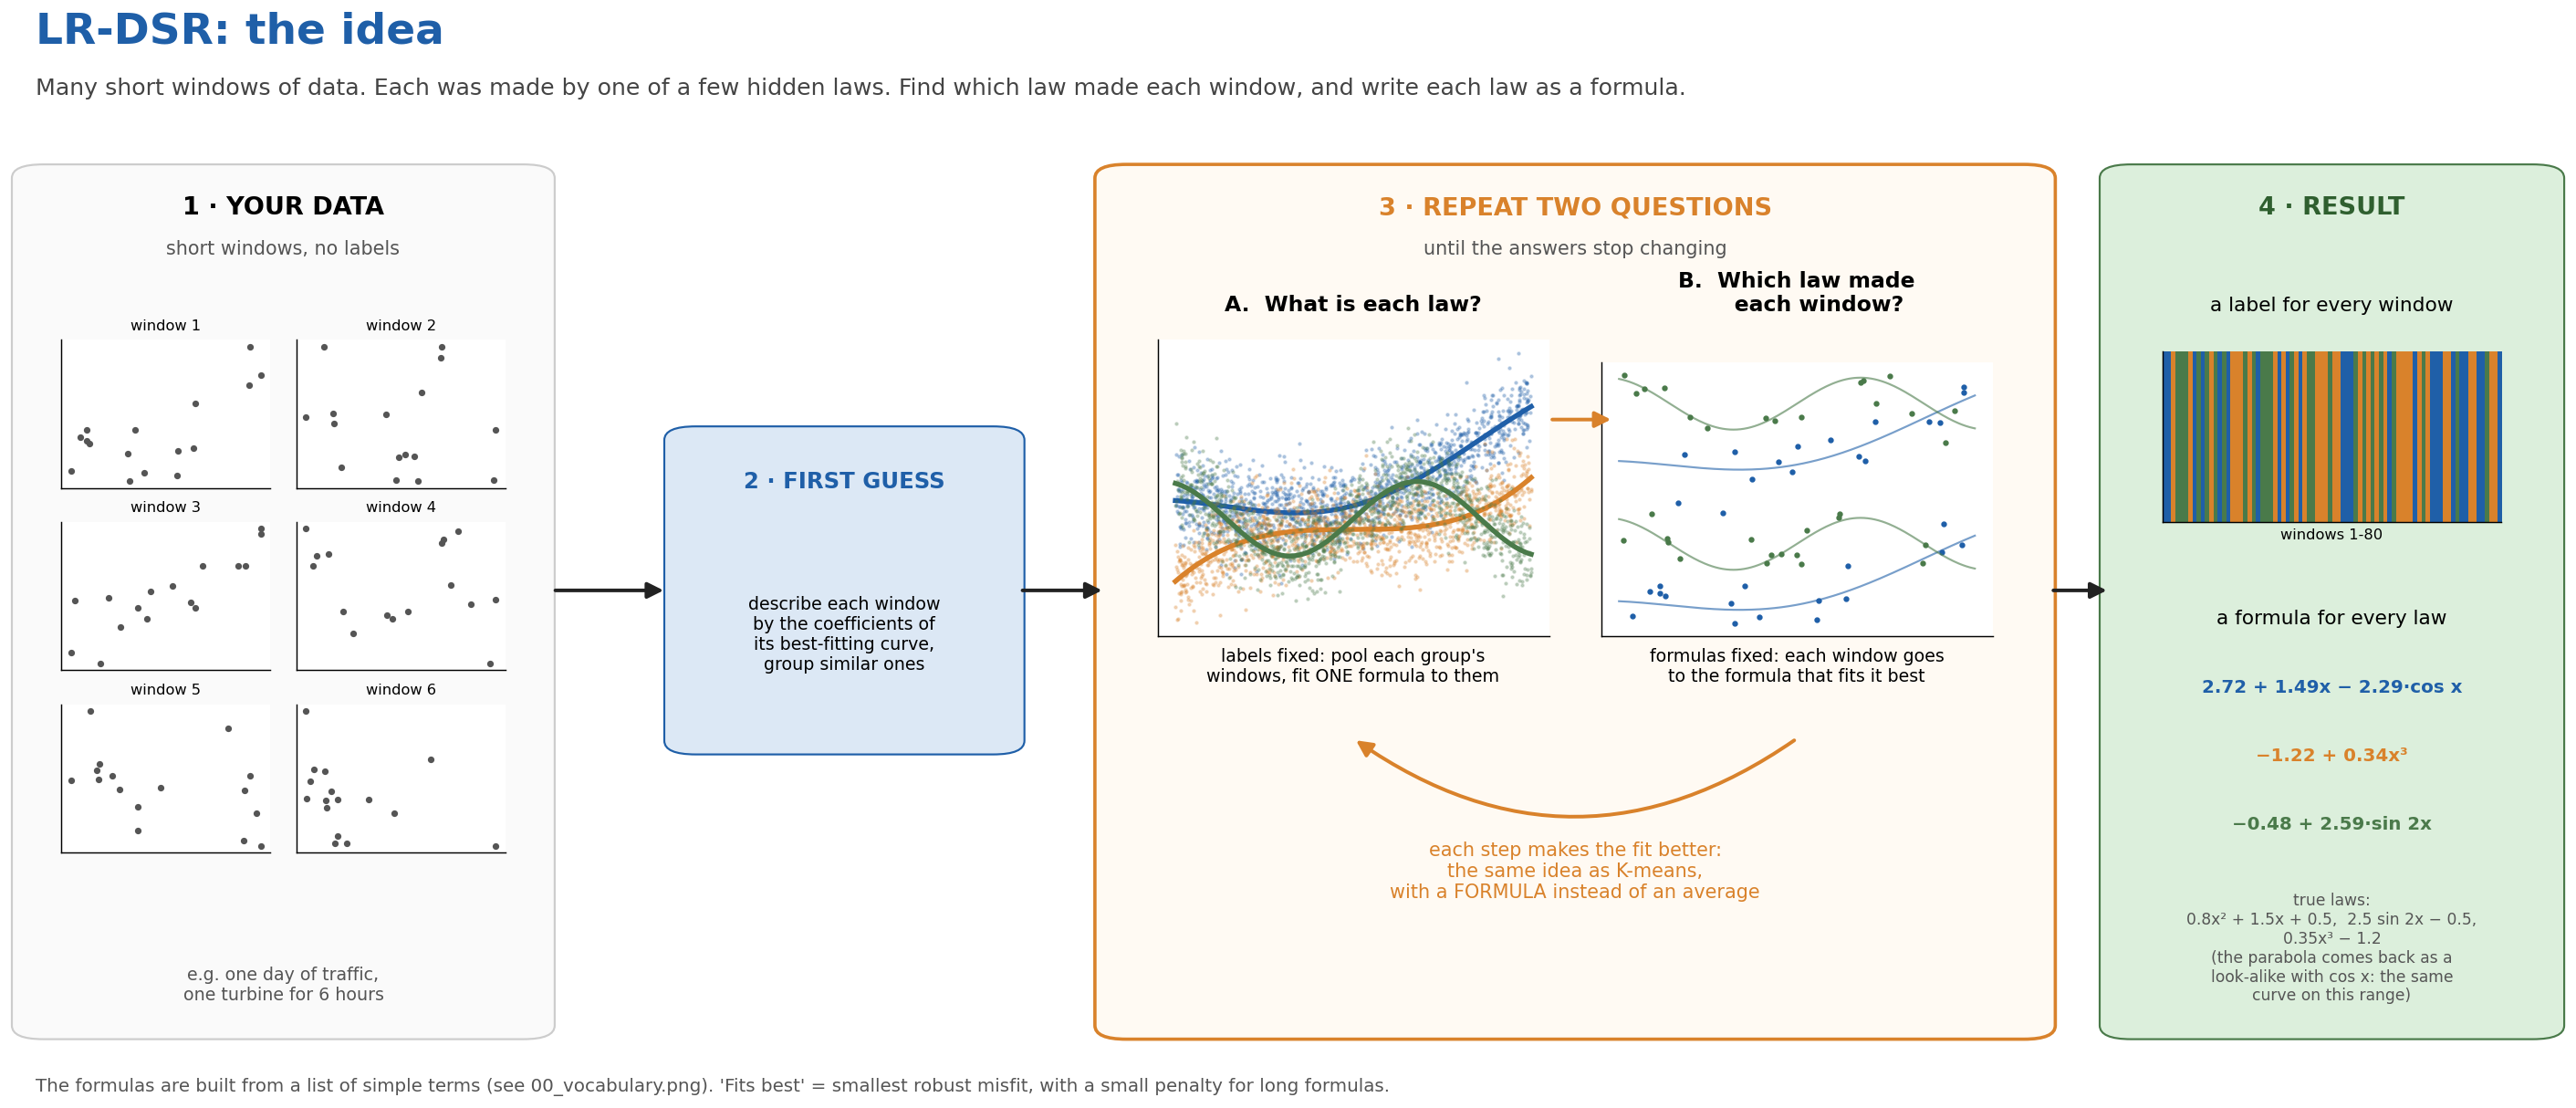

In [3]:
from IPython.display import Image
Image(filename=str(ROOT / "docs" / "algorithm" / "00_the_idea.png"), width=1050)

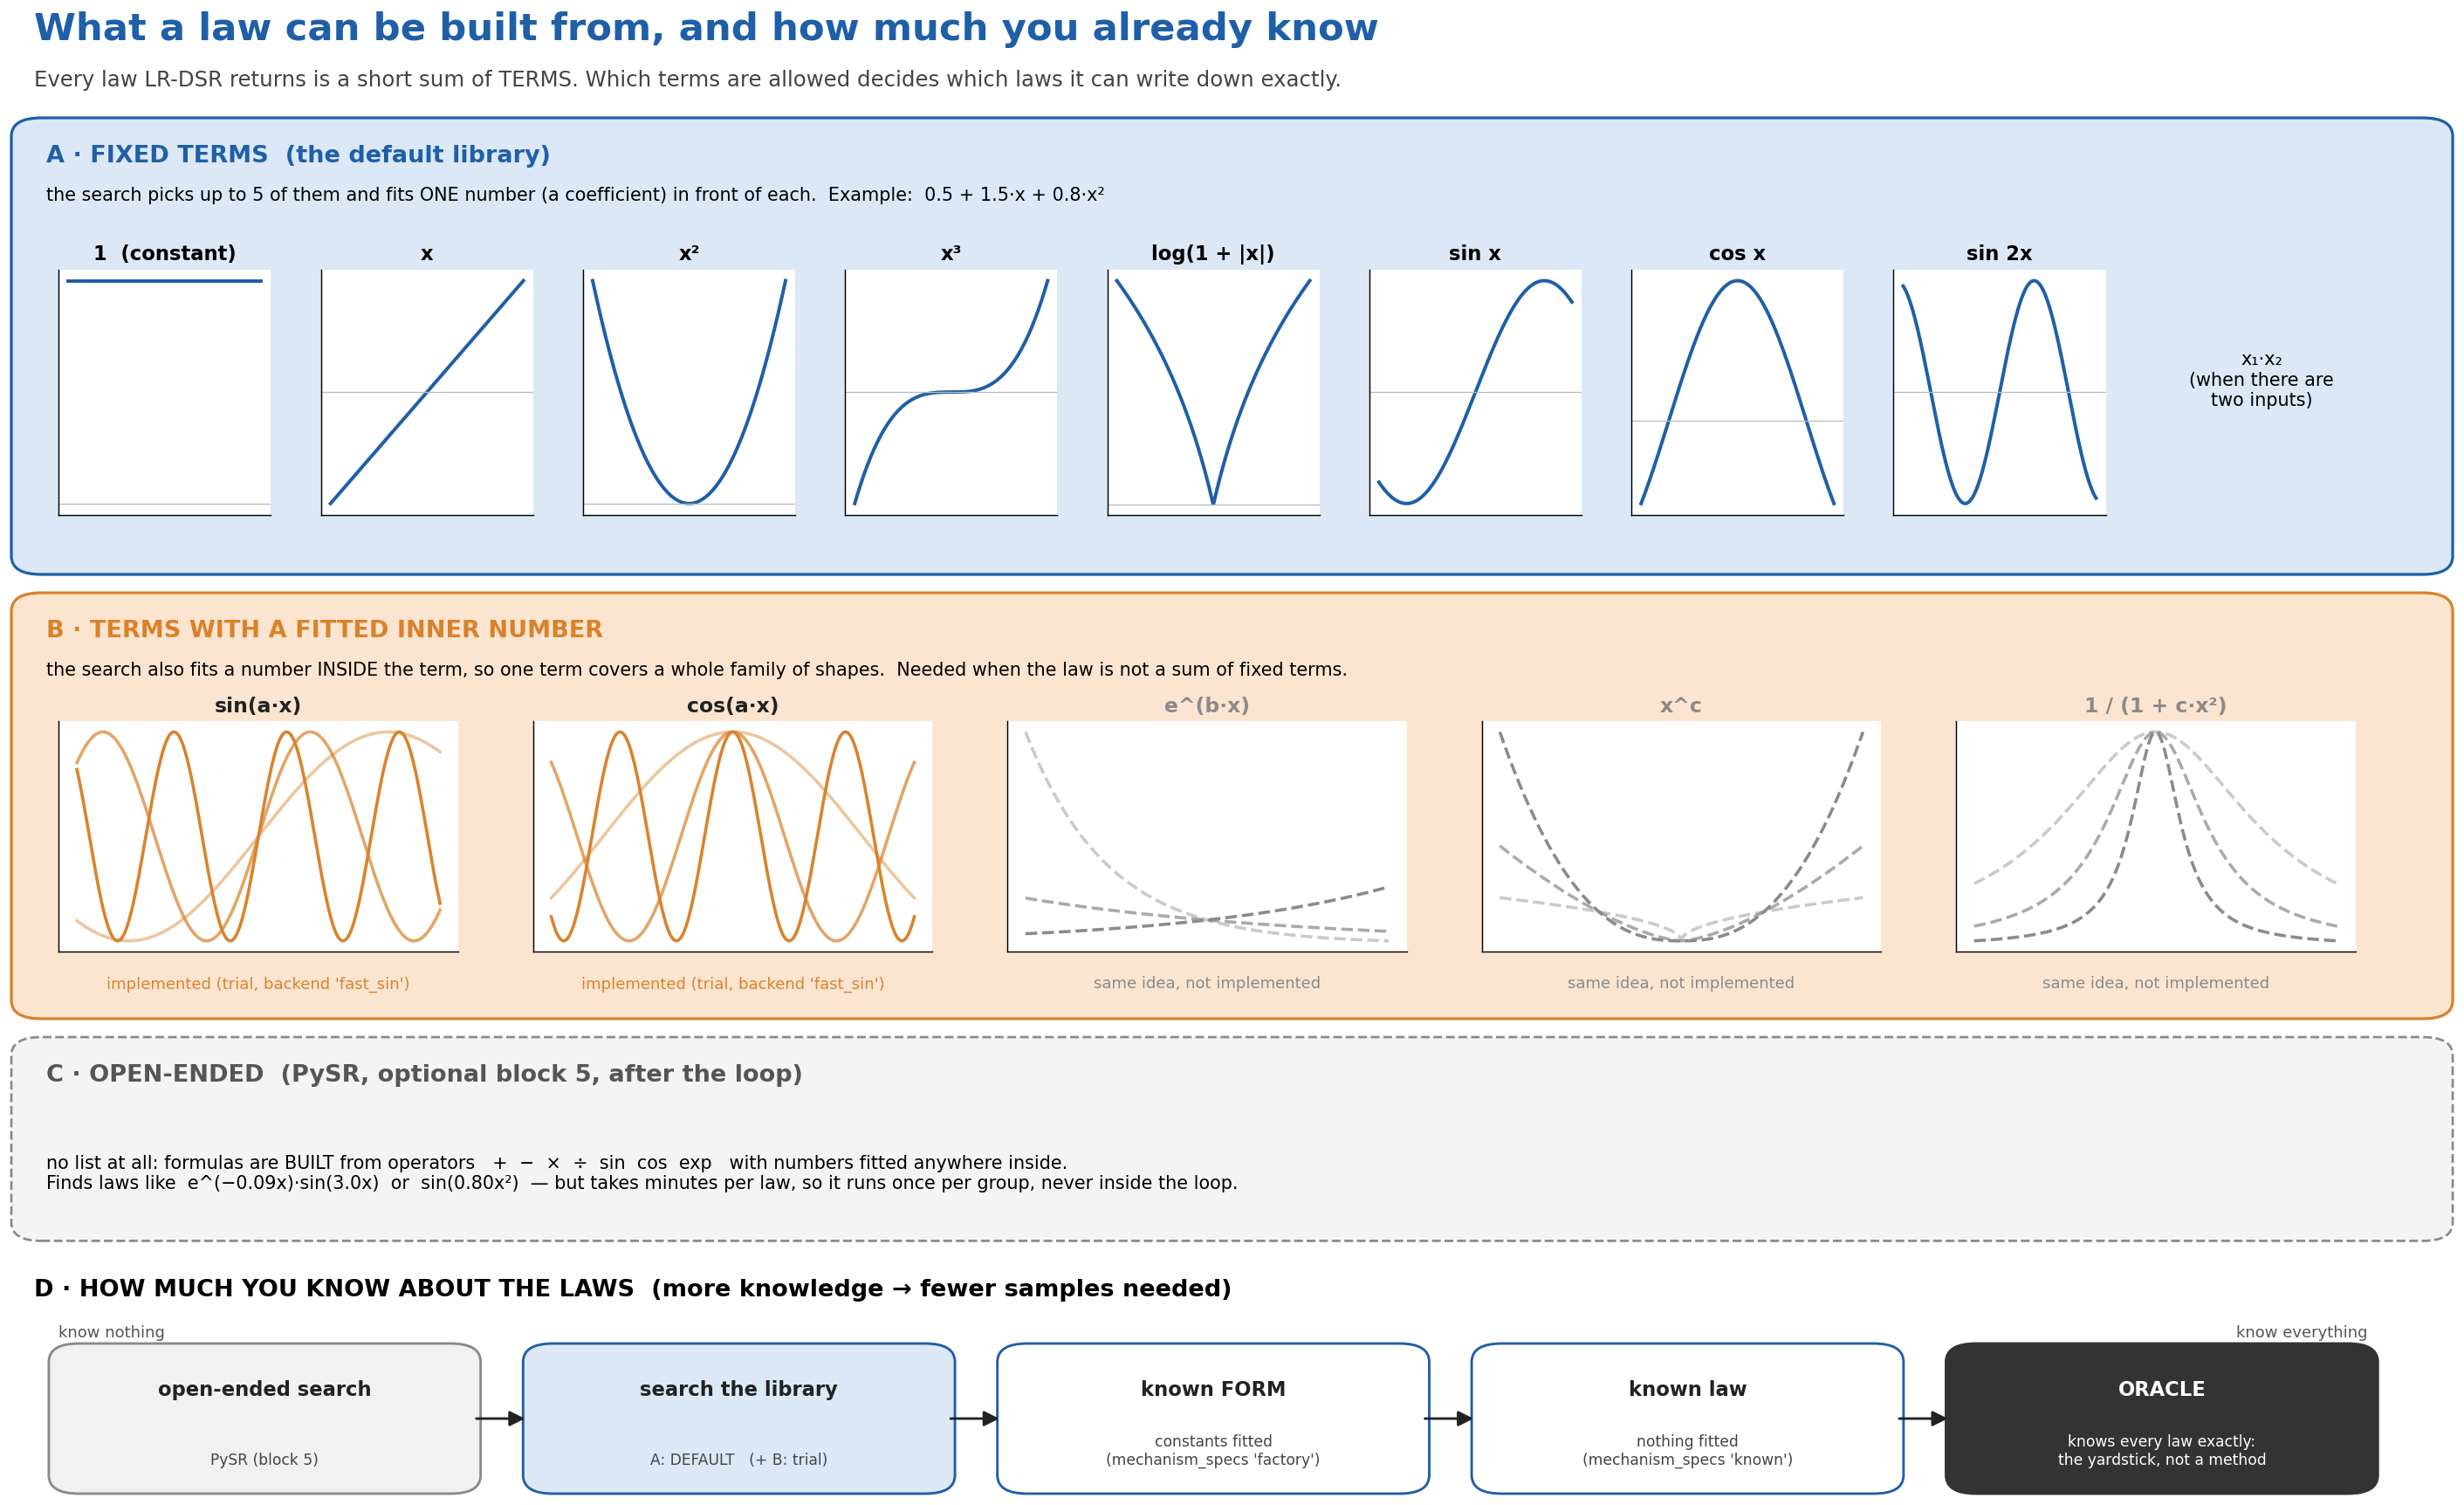

In [4]:
Image(filename=str(ROOT / "docs" / "algorithm" / "00_vocabulary.png"), width=1050)

## 2.1 The model

We observe $W$ windows. Window $w$ has $n$ input/output pairs
$(x_{w1}, y_{w1}), \dots, (x_{wn}, y_{wn})$. The model is

$$
y_{wi} \;=\; f_{z_w}(x_{wi}) + \varepsilon_{wi}, \qquad z_w \in \{1,\dots,K\},
\qquad \varepsilon_{wi} \sim \text{noise of scale } \sigma .
$$

* $f_1, \dots, f_K$ -- the $K$ unknown laws (the *mechanisms*);
* $z_w$ -- the hidden label: which law produced window $w$ (never observed);
* each law is a short sum of terms from a **library** of simple functions,
  $f_k(x) = \beta_{k0} + \sum_{j \in S_k} \beta_{kj}\,\phi_j(x)$,
  with $\phi_j \in \{x, x^2, x^3, \log(1+|x|), \sin x, \cos x, \sin 2x, x_a x_b\}$
  and at most 5 terms. That is what makes the result a readable formula.

## 2.2 The objective function

Recover the labels and the laws together by minimising one cost:

$$
\min_{z,\; f_1..f_K}\;\; \sum_{w=1}^{W} J_w(z_w),
\qquad
J_w(k) \;=\; \underbrace{\frac{1}{n}\sum_{i=1}^{n}\rho\!\left(\frac{y_{wi} - f_k(x_{wi})}{\hat s}\right)}_{\text{how badly law } k \text{ explains window } w}
\;+\; \beta\,C(f_k) \;+\; \alpha\,D_\text{geom}(w,k)
$$

* $\rho$ -- the per-sample **loss**. Default: **Huber** (quadratic for small
  residuals, linear for large ones, so one outlier cannot dominate). Squared,
  Cauchy, Tukey, Student-t, or a **learned** loss are options.
* $\hat s$ -- **one shared noise scale** (robust spread of all residuals), so a
  window a law explains badly really costs more.
* $C(f_k)$ -- the number of terms (a small complexity penalty, $\beta = 0.002$).
* $D_\text{geom}$ -- an optional "where the window sits" term. The default is
  $\alpha = 0$: assignment is **by the law only**.

## 2.3 The optimisation: alternate two easy problems

The objective is hard jointly (labels are discrete, the law's *form* is
discrete too), but each half is easy with the other fixed. This is **block
coordinate descent** -- the same idea as K-means or hard EM, with "centroid"
replaced by "law":

| step | fixed | solved | how |
|---|---|---|---|
| 0 · start | -- | labels $z$ | K-means in **mechanism space** (2.4) |
| 1 · fit | labels $z$ | laws $f_k$ | per cluster, **greedy forward selection with BIC** over the library; coefficients by least squares |
| 2 · score | laws | cost matrix $J_w(k)$ | every window under **every** law, **out-of-fold** (cross-fit: a window is never scored by a law fitted on itself) |
| 3 · assign | cost matrix | labels $z$ | $z_w = \arg\min_k J_w(k)$; tiny clusters repaired |
| 4 · repeat | | | until fewer than 1% of windows move (max 10 rounds), then refit the laws |

*Greedy forward BIC* (step 1): start from a constant; at each round try adding
every library term, keep the one that lowers
$\mathrm{BIC} = N\log(\mathrm{RSS}/N) + p\log N$ the most; stop when nothing
lowers it or 5 terms are in. BIC trades fit ($\mathrm{RSS}$) against size ($p$
coefficients), so the law stays short. The engine is swappable (PySR, PhySO
are supported); this deterministic one is the default.

## 2.4 The start: mechanism space

The start matters, so it is not done on look-alike statistics either. Each
window is mapped to its **law coefficients**: regress the window on the
library, remove what every window shares, and whiten so that noise is equally
large in every direction ($s_w = C_w^\top r_w$, `lrdsr.core.mechanism_space`).
In that space each regime is a round blob, centres $\sqrt{n\rho}$ apart --
the setting where **plain K-means is the right rule**.

## 2.5 How well can anyone do? The ceiling

Even someone who **knows** both laws misclassifies a window sometimes, because
of noise. That best-possible error is a formula:

$$
P_\text{err} = Q\!\left(\tfrac{\sqrt{n\,\rho}}{2}\right), \qquad
\rho = \frac{\mathbb{E}\big[(f_1(x) - f_0(x))^2\big]}{\sigma^2}
\quad(\text{separation of the laws in noise units}),
$$

$Q$ the Gaussian tail. Every result below is measured **against this
ceiling** (the "oracle"), so "good" has a precise meaning: *close to what is
possible at all*.

## 2.6 Variants of the same idea

* **Soft EM** (`SoftLRDSR`): the same mixture, but each window gets a
  *probability* per law instead of a hard label; Gaussian or Student-t noise.
* **Real time** (`OnlineLRDSR`): window by window, microseconds each; a window
  no law explains is buffered and a consistent buffer becomes a **new law**.
* **Classification** (`LawClassifier`): with labels, fit $L$ laws per class and
  assign a new window to the class whose laws explain it best.

The pipeline end to end:

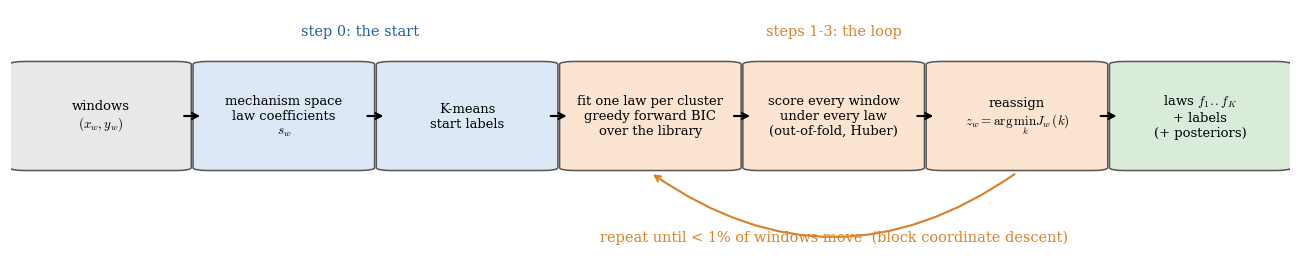

In [5]:
from matplotlib.patches import FancyBboxPatch

steps = [("windows\n$(x_w, y_w)$", "#e8e8e8"),
         ("mechanism space\nlaw coefficients\n$s_w$", "#dce8f5"),
         ("K-means\nstart labels", "#dce8f5"),
         ("fit one law per cluster\ngreedy forward BIC\nover the library", "#fbe5d0"),
         ("score every window\nunder every law\n(out-of-fold, Huber)", "#fbe5d0"),
         ("reassign\n$z_w = \\arg\\min_k J_w(k)$", "#fbe5d0"),
         ("laws $f_1..f_K$\n+ labels\n(+ posteriors)", "#d9ecd9")]
fig, ax = plt.subplots(figsize=(15, 2.9))
xs = np.linspace(0.07, 0.93, len(steps)); wbox = 0.118
for i, ((txt, col), x) in enumerate(zip(steps, xs)):
    ax.add_patch(FancyBboxPatch((x - wbox / 2, 0.36), wbox, 0.42, boxstyle="round,pad=0.012",
                                fc=col, ec="#555555", lw=1))
    ax.text(x, 0.57, txt, ha="center", va="center", fontsize=8.6)
    if i < len(steps) - 1:
        ax.annotate("", (xs[i + 1] - wbox / 2 - 0.004, 0.57), (x + wbox / 2 + 0.004, 0.57),
                    arrowprops={"arrowstyle": "->", "lw": 1.4})
ax.annotate("", (xs[3], 0.34), (xs[5], 0.34),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": viz.PALETTE[1],
                        "connectionstyle": "arc3,rad=-0.35"})
ax.text(xs[4], 0.06, "repeat until < 1% of windows move  (block coordinate descent)",
        ha="center", color=viz.PALETTE[1], fontsize=9.5)
ax.text(xs[1] + 0.06, 0.9, "step 0: the start", ha="center", color=viz.PALETTE[0], fontsize=9.5)
ax.text(xs[4], 0.9, "steps 1-3: the loop", ha="center", color=viz.PALETTE[1], fontsize=9.5)
ax.set(xlim=(0, 1), ylim=(0, 1)); ax.axis("off");

The library the laws are built from, and the three losses most used for the
equation term. The right panel is the *influence*: how hard one sample can
pull the fit. Squared loss lets an outlier pull without limit; Huber caps it.

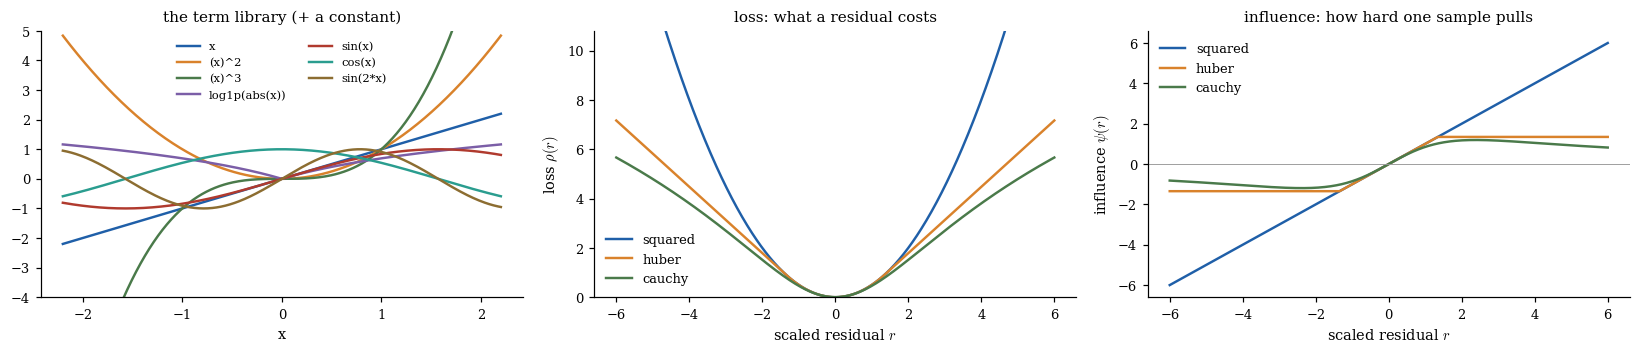

In [6]:
from lrdsr.core.soft import library_terms

xg = np.linspace(-2.2, 2.2, 300)
Phi, names = library_terms(xg[:, None], feature_names=["x"])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.3))
for j in range(1, Phi.shape[1]):
    ax[0].plot(xg, Phi[:, j], lw=1.6, color=viz.PALETTE[(j - 1) % len(viz.PALETTE)], label=names[j])
ax[0].set(title="the term library (+ a constant)", xlabel="x", ylim=(-4, 5))
ax[0].legend(fontsize=7.5, ncol=2, loc="upper center")
viz.plot_losses(ax=ax[1], losses=("squared", "huber", "cauchy"))
viz.plot_losses(ax=ax[2], losses=("squared", "huber", "cauchy"), influence=True)
ax[1].set_title("loss: what a residual costs"); ax[2].set_title("influence: how hard one sample pulls")
fig.tight_layout()

---
# 3 · A worked example, live

Three laws, 240 windows of 16 noisy samples each. The inputs of every window
are drawn from the same range, so *where* a window sits says nothing about
its law. The true labels are kept aside **for scoring only**.

true law 0:  y = 0.8*x^2 + 1.5*x + 0.5   (85 windows)
true law 1:  y = 2.5*sin(2*x) - 0.5   (73 windows)
true law 2:  y = 0.35*x^3 - 1.2   (82 windows)


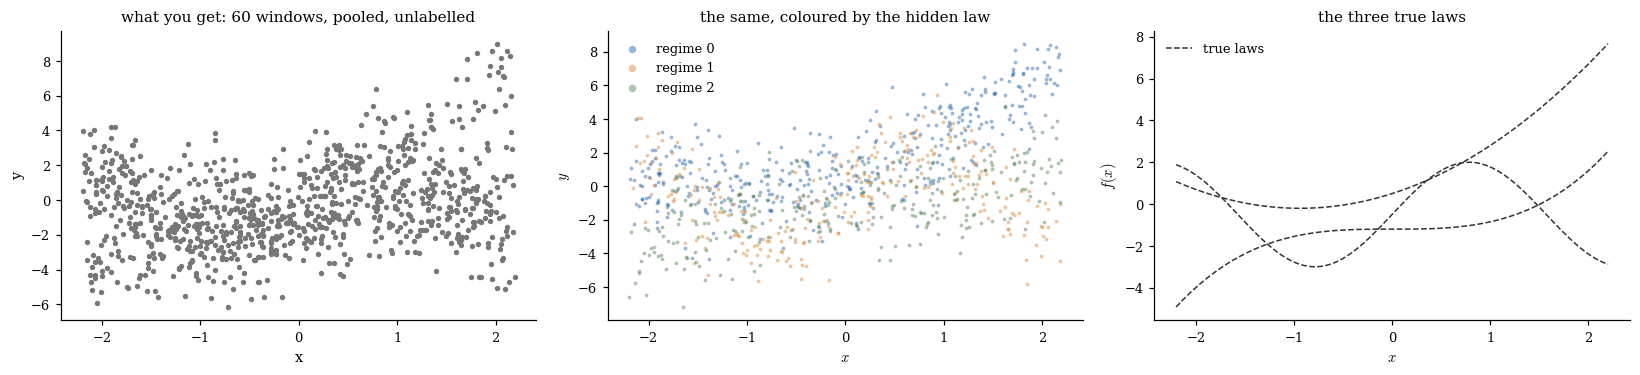

In [7]:
from experiments.functions.data import simulate_function_windows
from experiments.common.fitting import window_features
from lrdsr import GroupedDCSR, SoftLRDSR, FastSymbolicRegressor
from lrdsr.core.evaluation import aligned_accuracy

X, y, Zgeo, z, equations = simulate_function_windows(
    n_windows=240, window_len=16, noise_std=1.5, geometry_overlap=3.0, seed=11)
true_laws = [lambda x: 0.8 * x**2 + 1.5 * x + 0.5,
             lambda x: 2.5 * np.sin(2 * x) - 0.5,
             lambda x: 0.35 * x**3 - 1.2]
for k, e in enumerate(equations):
    print(f"true law {k}:  y = {e}   ({np.sum(z == k)} windows)")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].plot(X[:60, :, 0].ravel(), y[:60].ravel(), "o", ms=2.5, color="#777777")
ax[0].set(title="what you get: 60 windows, pooled, unlabelled", xlabel="x", ylabel="y")
viz.plot_windows(X, y, z, ax=ax[1], max_windows=60)
ax[1].set_title("the same, coloured by the hidden law")
viz.plot_laws(truth=true_laws, x_range=(-2.2, 2.2), ax=ax[2]); ax[2].set_title("the three true laws")
fig.tight_layout()

**Look-alike space vs. mechanism space.** Left: two window statistics (what a
standard clustering would use) -- the colours are mixed. Right: the same
windows in mechanism space -- three separate groups.

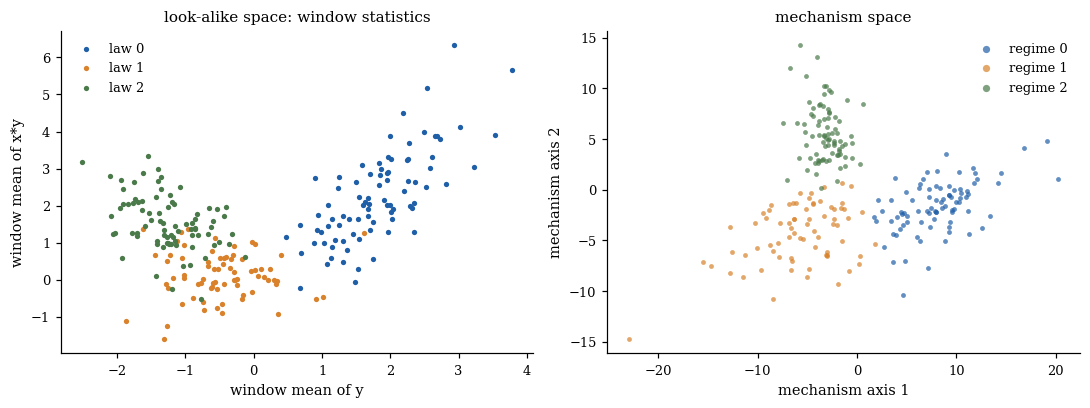

In [8]:
Zf, fnames = window_features(X, y)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for k in range(3):
    ax[0].scatter(Zf[z == k, 0], Zf[z == k, 5], s=12, color=viz.regime_color(k), lw=0, label=f"law {k}")
ax[0].set(title="look-alike space: window statistics", xlabel="window mean of y", ylabel="window mean of x*y")
ax[0].legend()
viz.plot_mechanism_space(X, y, z, ax=ax[1], feature_names=["x"])
fig.tight_layout()

**The loop, iteration by iteration.** To *see* the loop work, start it from a
bad partition on purpose (K-means on the look-alike statistics) and stop it
after 0, 1, 2 and all rounds. Solid: the laws fitted at that point; dashed:
the truth.

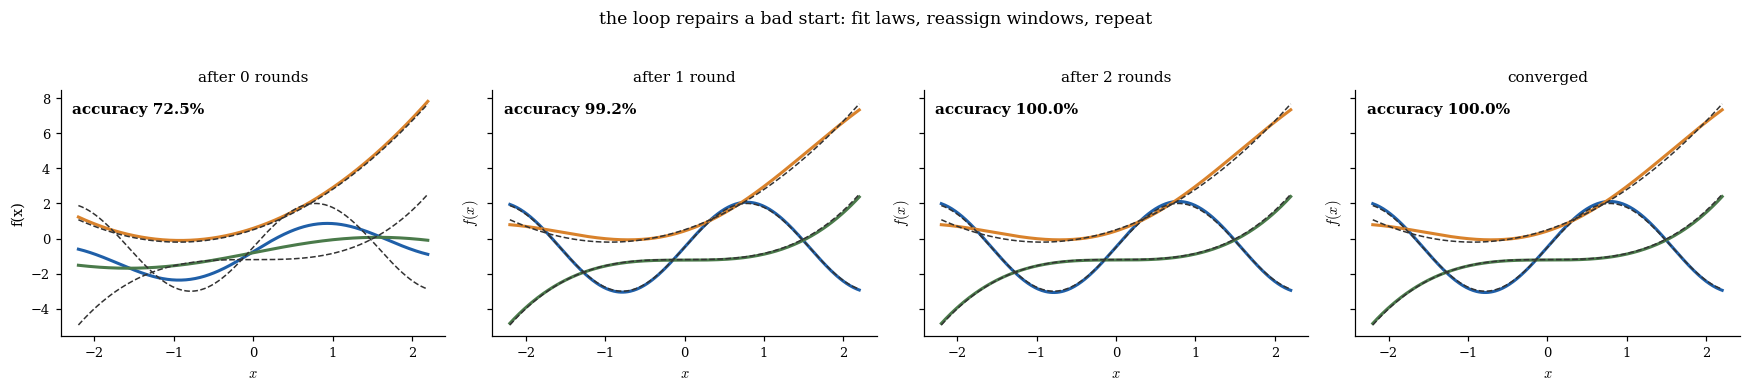

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

bad_start = KMeans(3, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(Zf))
cfg = {"n_clusters": 3, "alpha_geom": 0.0, "backend": "fast", "backend_kwargs": {"max_terms": 5},
       "score_mode": "cross_fit", "residual_scale": "global", "random_state": 11}
fig, ax = plt.subplots(1, 4, figsize=(16, 3.4), sharey=True)
for a, rounds in zip(ax, (0, 1, 2, 10)):
    r = GroupedDCSR(init=bad_start, max_iter=rounds, **cfg).fit(X, y, Zf, feature_names=["x"])
    viz.plot_laws(r.models, x_range=(-2.2, 2.2), truth=true_laws, ax=a)
    a.get_legend().remove()
    a.set_title(f"after {rounds} round{'s' * (rounds != 1)}" if rounds < 10 else "converged",
                fontsize=10)
    a.text(0.03, 0.95, f"accuracy {aligned_accuracy(z, r.labels):.1%}", transform=a.transAxes,
           va="top", fontsize=10, weight="bold")
ax[0].set_ylabel("f(x)")
fig.suptitle("the loop repairs a bad start: fit laws, reassign windows, repeat", y=1.03)
fig.tight_layout()

**The real fit** (the project default: start in mechanism space, Huber loss,
out-of-fold scoring, assignment by the law only). And, inside it, how the law
of one cluster is *built*: greedy forward selection adds one library term at a
time while BIC keeps falling.

In [10]:
res = GroupedDCSR(init="mechanism", **cfg).fit(X, y, Zf, feature_names=["x"], true_labels_for_eval=z)
print(f"accuracy {aligned_accuracy(z, res.labels):.1%}  in {len(res.history)} rounds\n")
for k, m in enumerate(res.models):
    print(f"recovered law {k}:  y = {m.expression()}")

# Greedy forward BIC, replayed step by step for the cluster holding the
# parabola: every round tries every remaining term and keeps the best one.
k_par = np.bincount(res.labels[z == 0]).argmax()
Xk = X[res.labels == k_par].reshape(-1, 1); yk = y[res.labels == k_par].ravel()
sr = FastSymbolicRegressor(max_terms=5, feature_names=["x"])
lib, nk = sr._make_library(Xk), len(yk)
chosen, best = [], sr._bic(yk, np.full(nk, yk.mean()), 1)
trace = [(0, {"constant": best}, "constant")]
for rnd in range(1, 6):
    cands = {}
    for j, term in enumerate(lib):
        if j not in chosen:
            Phi = np.column_stack([np.ones(nk)] + [lib[c].values for c in [*chosen, j]])
            coef, *_ = np.linalg.lstsq(Phi, yk, rcond=None)
            cands[term.name] = sr._bic(yk, Phi @ coef, Phi.shape[1])
    pick = min(cands, key=cands.get)
    trace.append((rnd, cands, pick if cands[pick] < best - 1e-6 else None))
    if cands[pick] >= best - 1e-6:
        break
    best = cands[pick]; chosen.append(next(j for j, t in enumerate(lib) if t.name == pick))

accuracy 100.0%  in 2 rounds

recovered law 0:  y = 2.7175 +1.4884*x -2.2863*cos(x)
recovered law 1:  y = -1.2222 +0.33956*(x)^3
recovered law 2:  y = -0.48016 +2.5939*sin(2*x)


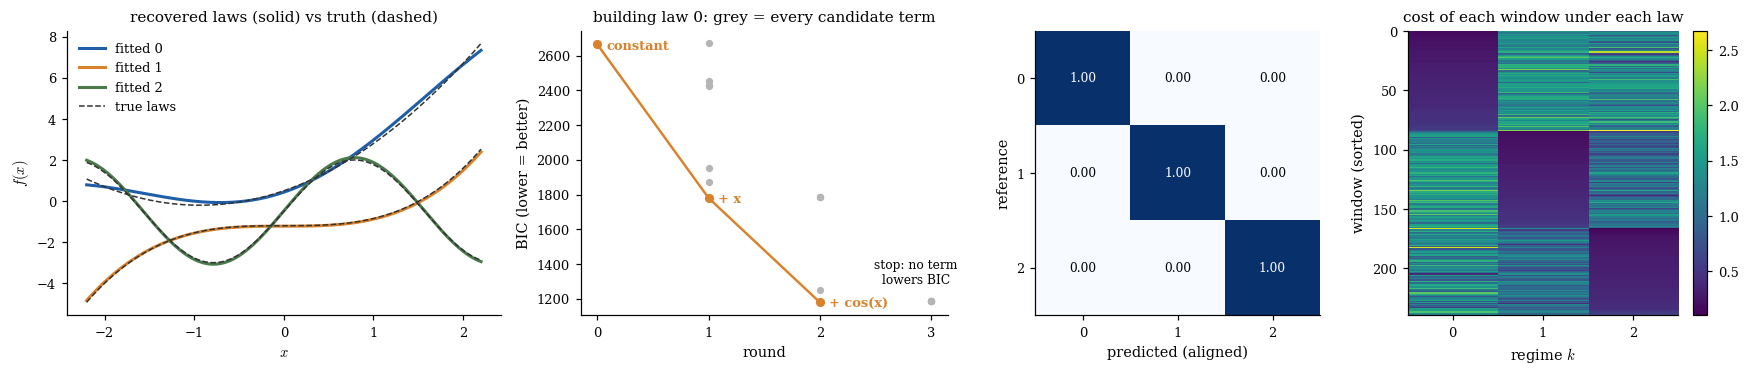

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3.5), gridspec_kw={"width_ratios": [1.3, 1.1, 0.9, 0.9]})
viz.plot_laws(res.models, x_range=(-2.2, 2.2), truth=true_laws, ax=ax[0])
ax[0].set_title("recovered laws (solid) vs truth (dashed)")
path = []
for rnd, cands, pick in trace:
    ax[1].scatter([rnd] * len(cands), list(cands.values()), s=14, color="#b5b5b5", zorder=2)
    if pick is not None:
        path.append((rnd, cands[pick]))
        ax[1].annotate(("+ " if rnd else "") + pick, (rnd, cands[pick]), textcoords="offset points",
                       xytext=(6, -3), fontsize=8.5, color=viz.PALETTE[1], weight="bold")
    else:
        ax[1].annotate("stop: no term\nlowers BIC", (rnd, min(cands.values())), textcoords="offset points",
                       xytext=(-10, 12), fontsize=8, ha="center")
ax[1].plot(*zip(*path), "-o", color=viz.PALETTE[1], zorder=3)
ax[1].set(title=f"building law {k_par}: grey = every candidate term", xlabel="round",
          ylabel="BIC (lower = better)", xticks=range(len(trace)))
viz.plot_confusion(z, res.labels, ax=ax[2])
viz.plot_cost_matrix(res.total_cost, res.labels, ax=ax[3])
ax[3].set_title("cost of each window under each law")
fig.tight_layout()

With 16 noisy points a window, a law can come back as an *equivalent*
formula rather than in its own symbols (e.g. $\cos x \approx 1 - x^2/2$ standing
in for part of a parabola). The curves agree where the data are, which is
what the left panel checks.

**The soft version** gives each window a probability per law, so you see
*how sure* each assignment is (right: one row per window, sorted).

soft EM accuracy 100.0%; 1.2% of windows are < 90% sure


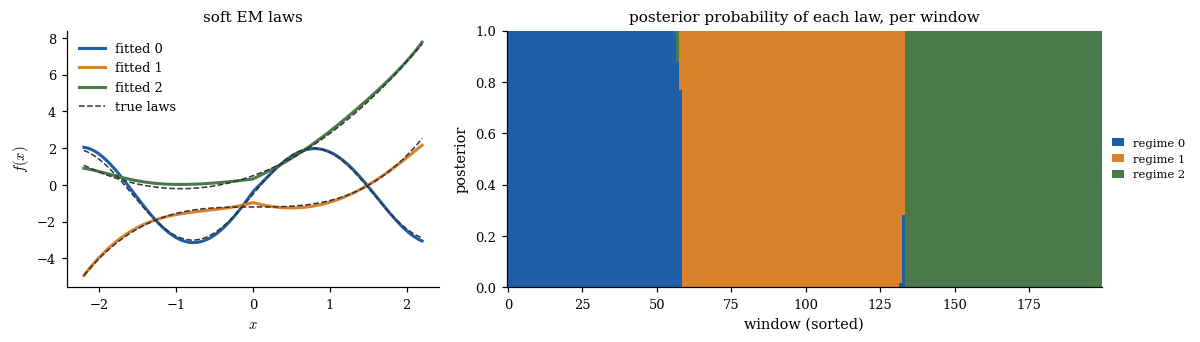

In [12]:
soft = SoftLRDSR(n_clusters=3, feature_names=["x"], random_state=11).fit(X, y)
unsure = np.mean(soft.responsibilities.max(1) < 0.9)
print(f"soft EM accuracy {aligned_accuracy(z, soft.labels):.1%}; {unsure:.1%} of windows are < 90% sure")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [1, 1.6]})
viz.plot_laws(coef=soft.coef, feature_names=["x"], x_range=(-2.2, 2.2), truth=true_laws, ax=ax[0])
ax[0].set_title("soft EM laws")
viz.plot_responsibilities(soft.responsibilities, ax=ax[1])
ax[1].set_title("posterior probability of each law, per window")
fig.tight_layout()

**How close to the ceiling is that?** At this noise level even the oracle --
who knows the true laws and labels each window by the smallest residual -- is
perfect, so turn the noise up. The method knows nothing and should stay near
the oracle; the look-alike clustering should not. (On one sample of 240
windows the method can land a hair *above* the oracle by chance; averaged over
seeds it does not -- the oracle is the ceiling.)

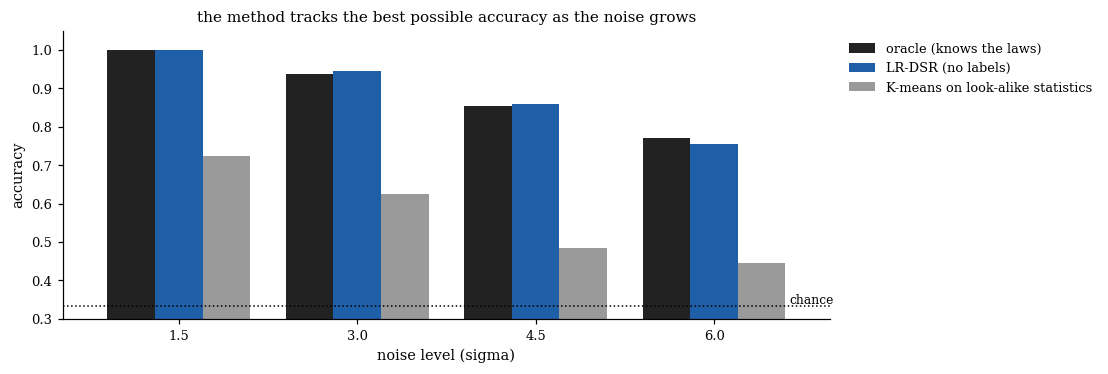

In [13]:
rows = []
for noise in (1.5, 3.0, 4.5, 6.0):
    Xn, yn, _, zn, _ = simulate_function_windows(n_windows=240, window_len=16, noise_std=noise,
                                                 geometry_overlap=3.0, seed=11)
    Zn, _ = window_features(Xn, yn)
    orc = np.column_stack([((yn - f(Xn[:, :, 0])) ** 2).sum(1) for f in true_laws]).argmin(1)
    fit = GroupedDCSR(init="mechanism", **cfg).fit(Xn, yn, Zn, feature_names=["x"])
    km = KMeans(3, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(Zn))
    rows.append({"noise": noise, "oracle (knows the laws)": np.mean(orc == zn),
                 "LR-DSR (no labels)": aligned_accuracy(zn, fit.labels),
                 "K-means on look-alike statistics": aligned_accuracy(zn, km)})
acc = pd.DataFrame(rows).set_index("noise")
ax = acc.plot.bar(figsize=(9, 3.4), color=["#222222", viz.PALETTE[0], "#9a9a9a"], width=0.8, rot=0)
ax.set(ylim=(0.3, 1.05), ylabel="accuracy", xlabel="noise level (sigma)",
       title="the method tracks the best possible accuracy as the noise grows")
ax.axhline(1 / 3, color="k", ls=":", lw=1); ax.text(3.42, 0.34, "chance", fontsize=8)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8.5);

### An honest note on the loop

The worked example started the loop from a bad partition to show it moving.
Measured systematically (mission 3), the loop turns out to be a
**stabiliser**: whatever quality of start it is given, it returns roughly the
same answer. It repairs a bad start a lot, but on the good mechanism-space
start it changes almost nothing (it can even cost a fraction of a percent).
The *start* does most of the work; the loop makes the method robust to a bad
one and is what produces the named laws.

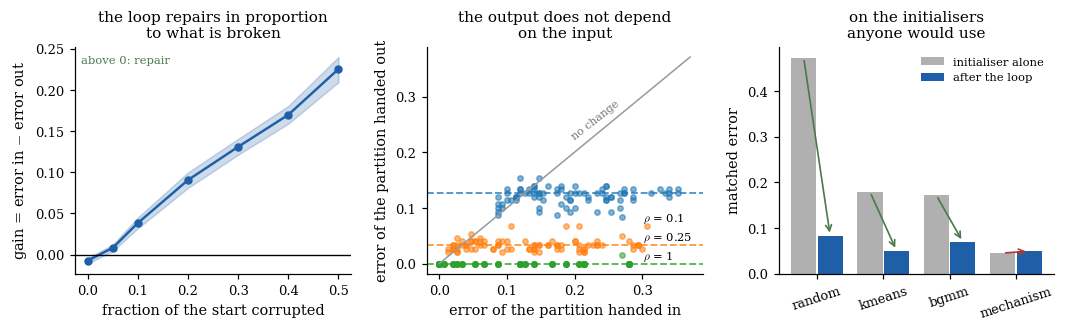

In [14]:
from analysis import plots as P
P.loop_value();

---
# 4 · What works: the main results

Each plot is read from the committed results (6 random seeds: tuned on 3,
reported on 3 others; true labels used only for scoring).

**The ceiling is reachable without labels.** Left: the measured error of the
oracle lies on the formula $Q(\sqrt{n\rho}/2)$. Right: K-means in mechanism
space (no labels) against that oracle, over 72 settings -- on the diagonal.

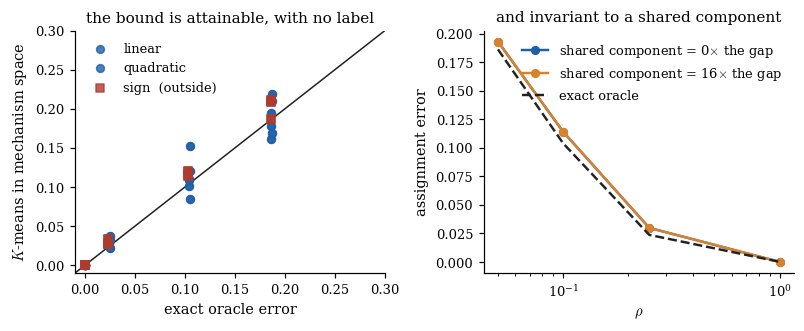

In [15]:
P.attainability();

**Robust and learned losses.** Under heavy-tailed noise the squared loss wastes
data; Huber and a *learned* loss (the method fits the noise distribution while
it clusters) reach the best possible error.

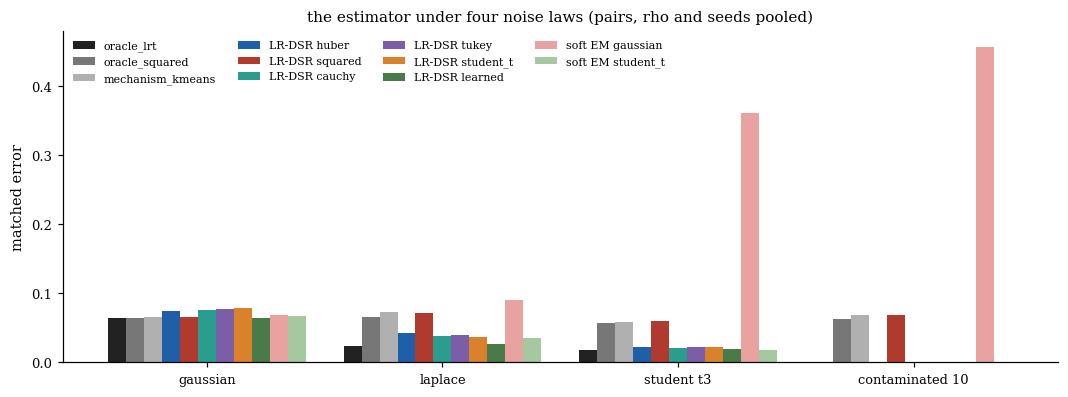

In [16]:
from analysis.figs_losses import FIGURES as LF
LF["loss_estimator"]();

**Real time.** A stream switches laws sample by sample; the detector finds each
switch after a delay the theory predicts (to a median 2.5%).

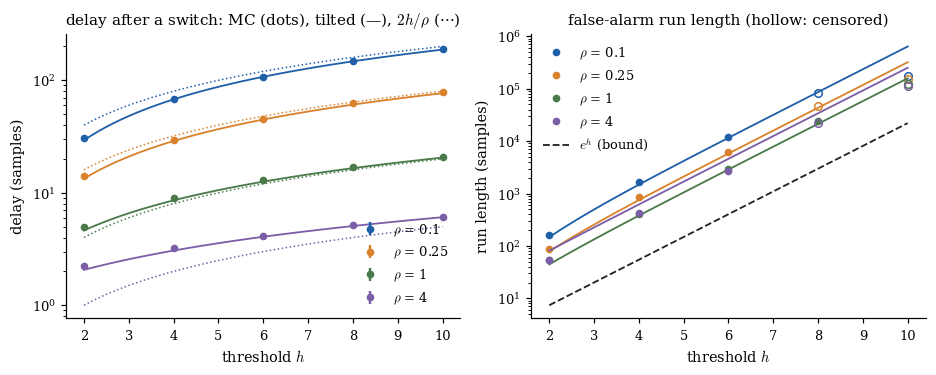

In [17]:
from analysis.figs_online import FIGURES as OF
OF["online_sequential"]();

**Days with sensor gaps.** Hourly highway traffic (I-94, Minneapolis). A law
does not need a complete day: it is evaluated at the hours that were observed.
On days with only 6-11 hours observed the law labels every day correctly; the
standard fix -- fill in the missing hours, then classify -- does not.

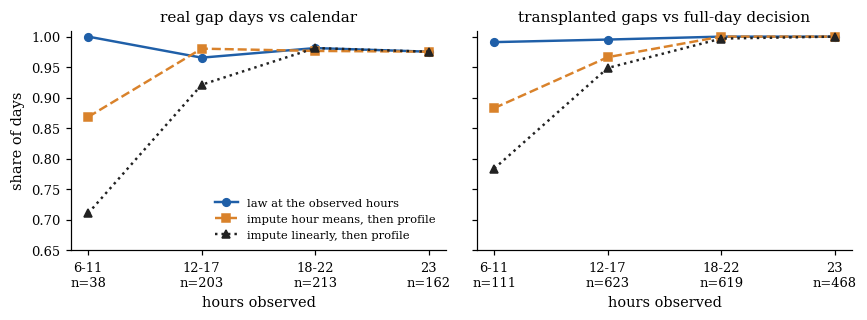

In [18]:
from analysis.figs_realdata import FIGURES as RF
RF["realdata_gaps"]();

**A new law appears in a stream.** With a flexible (kernel) basis the online
method *discovers* a law it had never seen and gives it its own group.

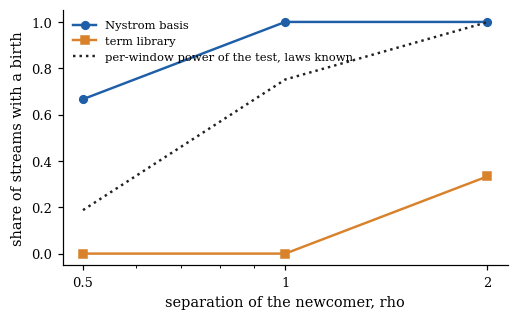

In [19]:
from analysis.figs_partial import FIGURES as PF
PF["online_kernel_birth"]();

**Classification, with a formula for its learning curve.** When labels exist,
the error as a function of the number of training windows is predicted
exactly by the theory (V10).

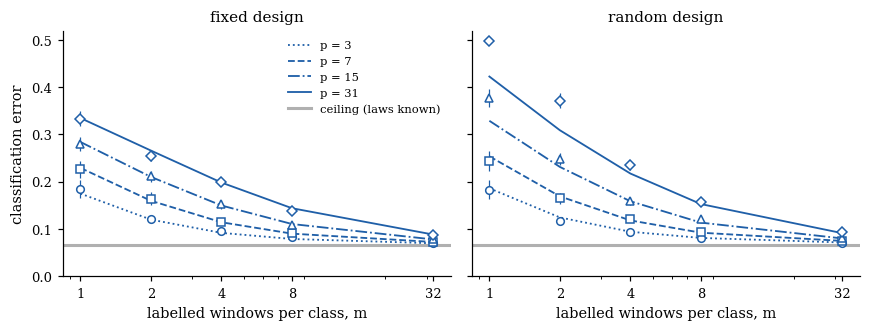

In [20]:
from analysis.figs_classify import FIGURES as CF
CF["v10_learning_curve"]();

**Wind turbines: every window has its own inputs.** Six-hour blocks of a real
wind farm (Kelmarsh, UK); each block sees different wind speeds, so there is no
common "profile" to compare. Laws separate cold from warm air and waked from
free flow better than the industry method of bins, on turbines never trained
on -- and the cold/warm power ratio lands on the air-density prediction.

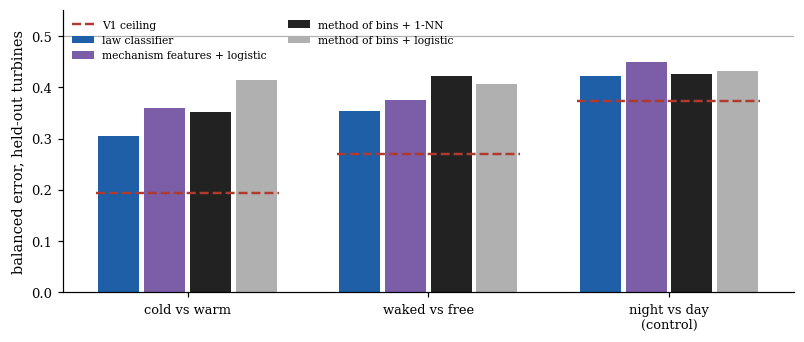

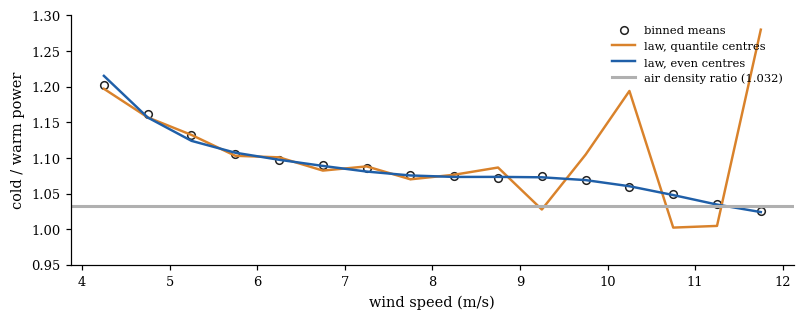

In [21]:
from analysis.figs_wind import FIGURES as WF
WF["wind_transfer"](); WF["wind_physics"]();

**Is this better than plain symbolic regression?** The natural competitor: run
the *same* symbolic-regression engine without the latent-regime structure --
one law for all windows ("pooled SR"), or one law per window and then cluster
the curves ("SR per window"). *These are the newest runs (2026-09-29) and are
not yet in `RESULTS.md`.*

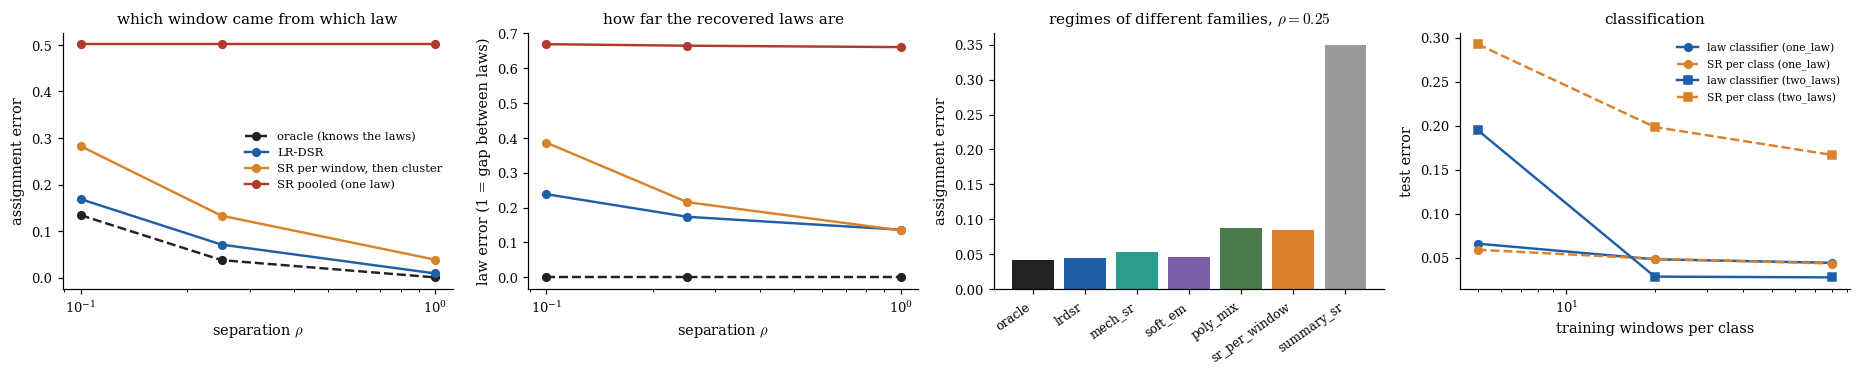

In [22]:
SB = RES / "srbaseline"
A = pd.read_csv(SB / "estimation_assignment.csv"); L = pd.read_csv(SB / "estimation_law.csv")
F = pd.read_csv(SB / "families_error.csv"); C = pd.read_csv(SB / "classification_summary.csv")
arms = [("oracle", "oracle (knows the laws)", "#222222", "--"), ("lrdsr", "LR-DSR", viz.PALETTE[0], "-"),
        ("sr_per_window", "SR per window, then cluster", viz.PALETTE[1], "-"),
        ("sr_pooled", "SR pooled (one law)", viz.PALETTE[4], "-")]
fig, ax = plt.subplots(1, 4, figsize=(17, 3.5))
for key, lab, c, ls in arms:
    ax[0].plot(A.rho, A[f"{key}_error"], ls, marker="o", color=c, label=lab)
    ax[1].plot(L.rho, L[f"{key}_law_error"], ls, marker="o", color=c, label=lab)
ax[0].set(xscale="log", title="which window came from which law", xlabel=r"separation $\rho$", ylabel="assignment error")
ax[1].set(xscale="log", title="how far the recovered laws are", xlabel=r"separation $\rho$", ylabel="law error (1 = gap between laws)")
ax[0].legend(fontsize=7.5)
f = F[F.suite == "families"].set_index("rho")
cols = [("oracle", "#222222"), ("lrdsr", viz.PALETTE[0]), ("mech_sr", viz.PALETTE[5]),
        ("soft_em", viz.PALETTE[3]), ("poly_mix", viz.PALETTE[2]), ("sr_per_window", viz.PALETTE[1]),
        ("summary_sr", "#999999")]
xp = np.arange(len(cols))
ax[2].bar(xp, [f.loc[0.25, c_] for c_, _ in cols], color=[c for _, c in cols])
ax[2].set_xticks(xp); ax[2].set_xticklabels([c_ for c_, _ in cols], rotation=35, ha="right", fontsize=8)
ax[2].set(title=r"regimes of different families, $\rho = 0.25$", ylabel="assignment error")
for s, mk in (("one_law", "o"), ("two_laws", "s")):
    g = C[C.structure == s]
    ax[3].plot(g.m, g.law_L1 if s == "one_law" else g.law_L2, "-" + mk, color=viz.PALETTE[0],
               label=f"law classifier ({s})")
    ax[3].plot(g.m, g.sr_per_class, "--" + mk, color=viz.PALETTE[1], label=f"SR per class ({s})")
ax[3].set(xscale="log", title="classification", xlabel="training windows per class", ylabel="test error")
ax[3].legend(fontsize=7)
fig.tight_layout()

Pooled SR is at chance (one law cannot describe two). Fitting a law to each
window first and clustering afterwards makes about **twice the assignment
error** of LR-DSR at low separation, because 16 noisy points are too few to
pin down a law -- pooling the windows of a cluster is the whole point. When
a class is made of *two* laws, the classifier that fits two laws per class
(right, squares) beats one SR law per class by a wide margin. One declared
prediction failed narrowly: at the largest separation SR-per-window's laws are
as good as LR-DSR's (0.135 vs 0.137).

---
# 5 · Real data, live: a year of bike sharing, on a calendar

Capital Bikeshare (Washington DC), hourly rentals 2011-12, **one window per
day**; the input is the hour of the day. The method is given $K=2$ and no
labels. Afterwards we compare with the calendar (working day or not) -- a
*proxy* for the truth, not the truth.

723 days; agreement with the calendar: 98.6%


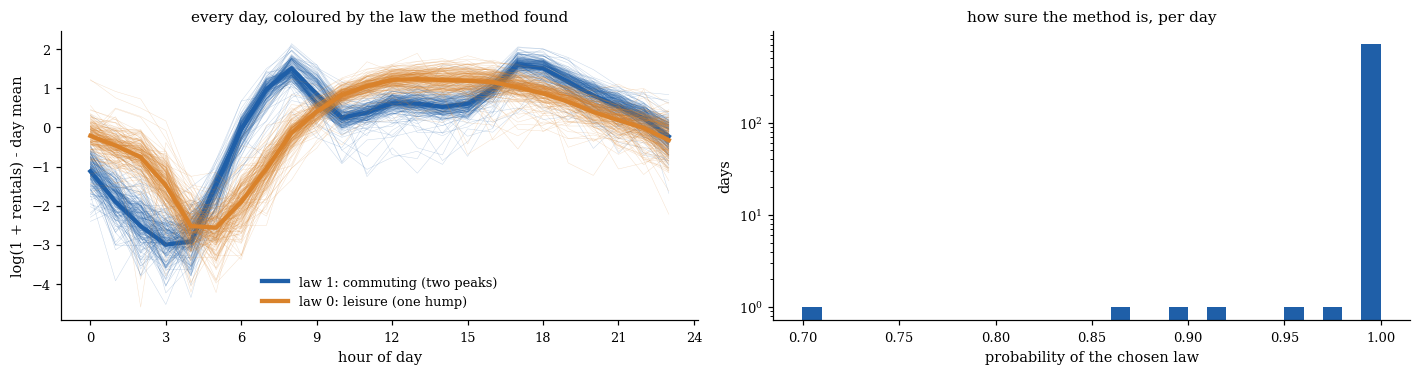

In [23]:
from experiments.realdata.windows import load
from experiments.realdata.run import fourier

bike = load("bike")
sb = SoftLRDSR(2, basis=fourier, noise="student_t", random_state=11).fit(bike.X_seq, bike.y_seq)
lab = sb.labels if np.mean(sb.labels == bike.reference) > 0.5 else 1 - sb.labels   # 1 = working-day law
print(f"{len(lab)} days; agreement with the calendar: {np.mean(lab == bike.reference):.1%}")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
hours = np.arange(24)
for k, name in ((1, "law 1: commuting (two peaks)"), (0, "law 0: leisure (one hump)")):
    sel = np.flatnonzero(lab == k)
    ax[0].plot(hours, bike.y_seq[sel[:200]].T, color=viz.regime_color(1 - k), lw=0.3, alpha=0.25)
    ax[0].plot(hours, bike.y_seq[sel].mean(0), color=viz.regime_color(1 - k), lw=2.8, label=name)
ax[0].set(title="every day, coloured by the law the method found", xlabel="hour of day",
          ylabel="log(1 + rentals) - day mean", xticks=range(0, 25, 3)); ax[0].legend(loc="lower center")
ent = sb.entropy
ax[1].hist(sb.responsibilities.max(1), bins=30, color=viz.PALETTE[0])
ax[1].set(title="how sure the method is, per day", xlabel="probability of the chosen law", ylabel="days", yscale="log")
fig.tight_layout()

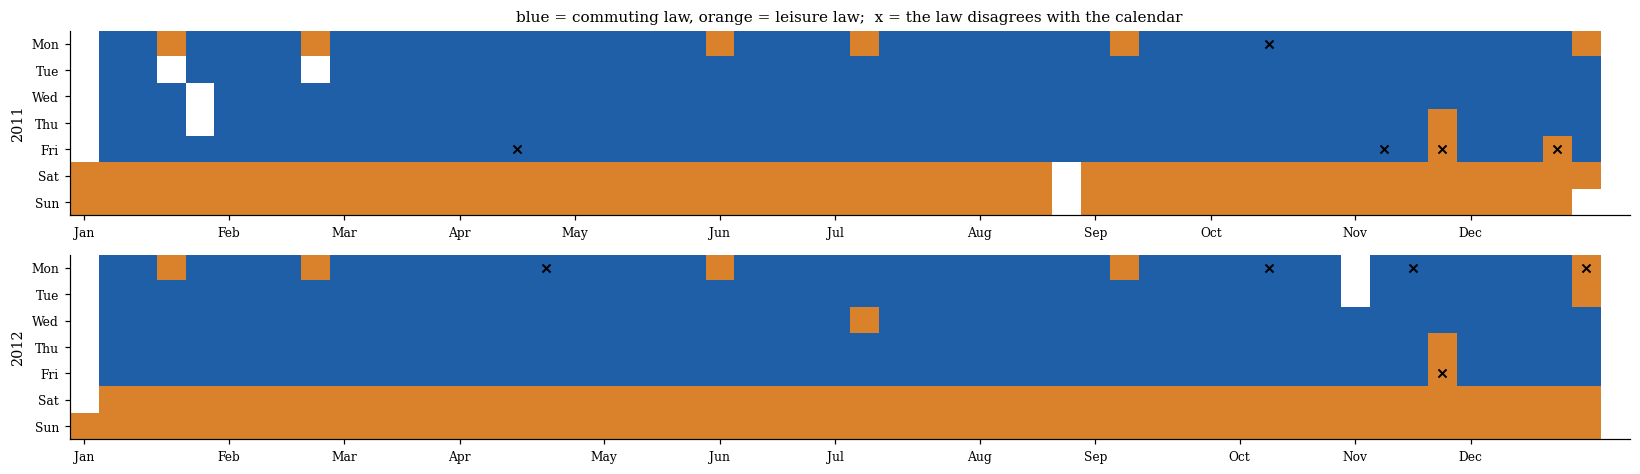

In [24]:
dates = pd.to_datetime(pd.Series(bike.dates))
fig, axes = plt.subplots(2, 1, figsize=(15, 4.4))
from matplotlib.colors import ListedColormap
cmap = ListedColormap([viz.regime_color(1), viz.regime_color(0)])
for a, year in zip(axes, sorted(dates.dt.year.unique())):
    m = (dates.dt.year == year).to_numpy()
    d = dates[m]; wk = d.dt.isocalendar().week.to_numpy().astype(int); dow = d.dt.dayofweek.to_numpy()
    wk = np.where((d.dt.month == 1).to_numpy() & (wk > 50), 0, wk)
    grid = np.full((7, 54), np.nan); grid[dow, wk] = lab[m]
    a.imshow(grid, aspect="auto", cmap=cmap, vmin=0, vmax=1, interpolation="none")
    odd = lab[m] != bike.reference[m]
    a.scatter(wk[odd], dow[odd], marker="x", color="k", s=28, lw=1.3)
    a.set_yticks(range(7)); a.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], fontsize=8)
    starts = d.groupby(d.dt.month).apply(lambda s: s.dt.isocalendar().week.iloc[0]).to_numpy().astype(int)
    starts[0] = 0
    a.set_xticks(starts); a.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug",
                                             "Sep", "Oct", "Nov", "Dec"], fontsize=8)
    a.set_ylabel(str(year))
axes[0].set_title("blue = commuting law, orange = leisure law;  x = the law disagrees with the calendar")
fig.tight_layout()

Weekends and the big holidays (Memorial Day, July 4th, Labor Day,
Thanksgiving, ...) are found without being told what a weekend or a holiday
is. The crosses are where law and calendar disagree, and they are of two
kinds: official holidays most people still work (Columbus Day, Veterans Day,
DC Emancipation Day -- the law says *commuting*), and days off the calendar
does not know about (the Friday after Thanksgiving, Christmas Eve -- the law
says *leisure*). In both the law is arguably right and the calendar wrong. On this data every day has the same 24 inputs, so here a
simpler clustering of the raw 24-hour profile ties the method (mission 7); the
method's edge on real data appears when the inputs differ -- days with
missing hours (above) and wind turbines.

---
# 6 · What did not work

### Failure 1: a law the library cannot write -- and a fix (trial)

Two fast oscillations, $\sin 4x$ vs. $\sin 4.6x$. The library's fastest term
is $\sin 2x$, so no combination of its terms can follow them: about 37% of the
difference between the two laws is invisible to it.

**The trial fix** keeps the problem, the objective and the loop exactly as
they are, and only gives the per-cluster fit a richer vocabulary: two new term
types, $\sin(a\,x)$ and $\cos(a\,x)$, whose frequency $a$ is **fitted**
(`SinusoidSymbolicRegressor`, backend `"fast_sin"`). For every $a$ on a grid
the coefficient is ordinary least squares, the best $a$ is refined locally,
and BIC charges the term one extra parameter for $a$. It competes with the
fixed terms, so it is used only when a sinusoid explains the data better.

Every method on the **same windows** (240 windows of 32 samples), at two
noise levels -- noisy ($\rho = 0.25$) and clean ($\rho = 1$):

| family | methods |
|---|---|
| the ceiling | **oracle** -- knows the true laws |
| this project | **LR-DSR + fitted frequency** (the trial), LR-DSR with the standard library, soft EM, mechanism K-means |
| signal processing | **periodogram + K-means** (Lomb-Scargle, the standard tool for oscillations), peak frequency + K-means |
| plain symbolic regression | a law per window, then K-means on the fitted curves -- with the standard library, and with the same fitted-frequency term |
| clustering the data | K-means on the raw curve, K-means on window summaries |

In [25]:
from experiments.problems import zoo
from experiments.problems.sinusoid_trial import FREQ_GRID, _kmeans, _periodogram, _sr_per_window, fit as fit_hf
from lrdsr.core.mechanism_space import mechanism_init

prob = zoo.PROBLEM_BY_NAME["high_frequency"]
truth_hf = [lambda x: np.sin(4 * x), lambda x: np.sin(4.6 * x)]
grid_hf = zoo.eval_grid(prob, 200)
METHODS_HF = [  # (key, label, colour)
    ("oracle", "oracle (knows the laws)", "#222222"),
    ("lrdsr_sin", "LR-DSR + fitted frequency", viz.PALETTE[0]),
    ("mech", "mechanism K-means", "#6f9fd8"), ("soft", "soft EM (library)", "#6f9fd8"),
    ("lrdsr", "LR-DSR, standard library", "#6f9fd8"),
    ("pgram", "periodogram + K-means", viz.PALETTE[1]), ("peak", "peak frequency + K-means", viz.PALETTE[1]),
    ("sr_sin", "SR per window (fitted freq.)", viz.PALETTE[2]), ("sr", "SR per window (library)", viz.PALETTE[2]),
    ("profile", "K-means, raw curve", "#9a9a9a"), ("summ", "K-means, window summaries", "#9a9a9a")]

runs = {}
for rho in (0.25, 1.0):
    X_, y_, z_ = zoo.make_windows(prob, zoo.sigma_for_rho(prob, rho), n_windows=240, window_len=32, seed=11)
    Z_, _ = window_features(X_, y_)
    P_ = _periodogram(X_, y_)
    lib_fit, sin_fit = (fit_hf(be, X_, y_, Z_, ["x"], 2, 11) for be in ("fast", "fast_sin"))
    lab = {"oracle": zoo.oracle_labels(prob, X_, y_), "lrdsr_sin": sin_fit.labels, "lrdsr": lib_fit.labels,
           "soft": SoftLRDSR(2, feature_names=["x"], random_state=11).fit(X_, y_).labels,
           "mech": mechanism_init(X_, y_, 2, seed=11, feature_names=["x"]),
           "pgram": _kmeans(P_, 2, 11), "peak": _kmeans(FREQ_GRID[P_.argmax(1)], 2, 11),
           "sr_sin": _sr_per_window("fast_sin", X_, y_, ["x"], grid_hf, 2, 11),
           "sr": _sr_per_window("fast", X_, y_, ["x"], grid_hf, 2, 11),
           "profile": _kmeans(np.take_along_axis(y_, np.argsort(X_[..., 0], 1), 1), 2, 11),
           "summ": _kmeans(Z_, 2, 11)}
    runs[rho] = {"acc": {k: aligned_accuracy(z_, v) for k, v in lab.items()},
                 "fits": (lib_fit, sin_fit), "P": P_, "z": z_}

print(f"{'accuracy':34s} {'noisy (rho=0.25)':>17s} {'clean (rho=1)':>14s}")
for key, name, _ in METHODS_HF:
    print(f"{name:34s} {runs[0.25]['acc'][key]:17.1%} {runs[1.0]['acc'][key]:14.1%}")
for tag, m_ in zip(("standard library", "+ fitted frequency"), runs[0.25]["fits"]):
    print(f"\nLR-DSR, {tag} (noisy):"); [print("   y =", m.expression()) for m in m_.models]

accuracy                            noisy (rho=0.25)  clean (rho=1)
oracle (knows the laws)                        89.6%         100.0%
LR-DSR + fitted frequency                      90.0%         100.0%
mechanism K-means                              86.2%          97.5%
soft EM (library)                              82.5%          97.1%
LR-DSR, standard library                       78.8%          90.0%
periodogram + K-means                          67.1%          98.8%
peak frequency + K-means                       55.0%          98.8%
SR per window (fitted freq.)                   54.6%          99.6%
SR per window (library)                        51.2%          52.1%
K-means, raw curve                             64.6%          62.9%
K-means, window summaries                      53.8%          54.6%

LR-DSR, standard library (noisy):
   y = -0.0067717 -0.19618*sin(x) +0.10578*sin(2*x)
   y = -0.010483 -0.11872*(x)^3 +0.48718*x -0.5199*sin(2*x)

LR-DSR, + fitted frequency (noisy):


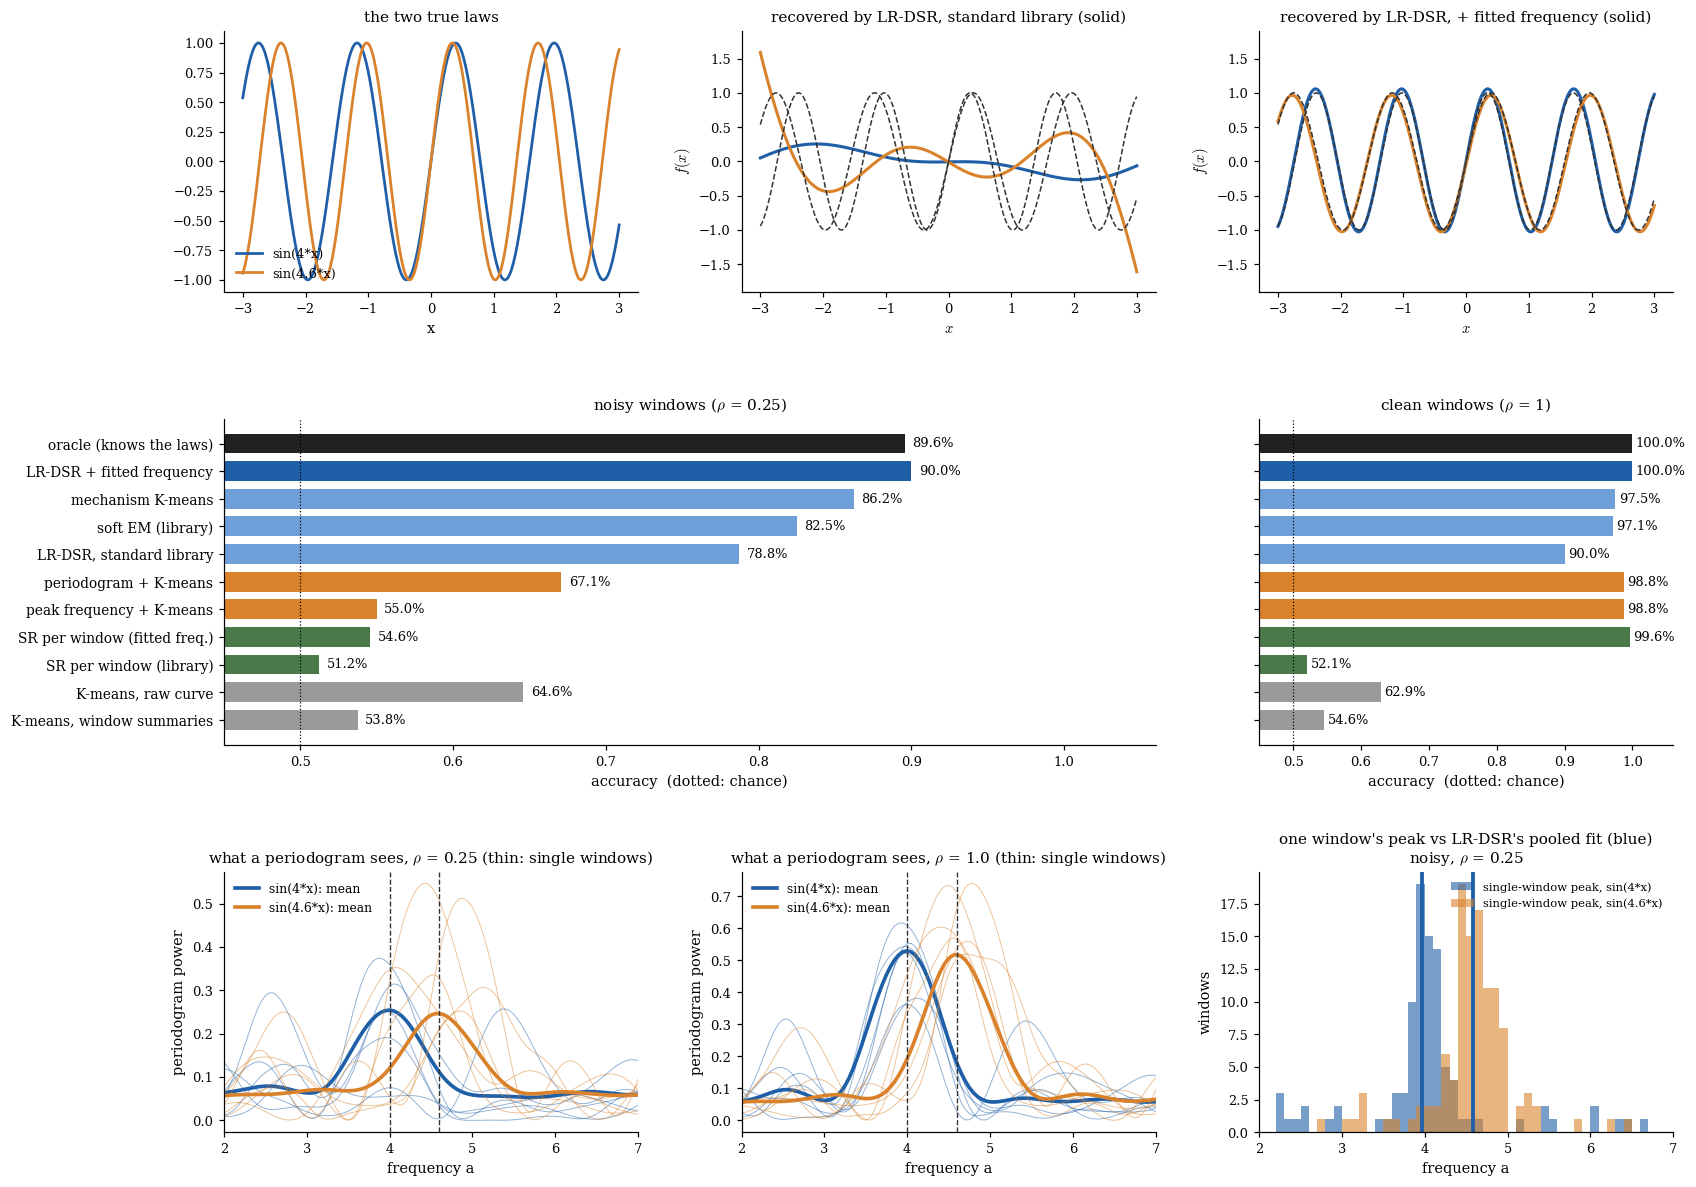

In [26]:
fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.25, 1], hspace=0.45, wspace=0.25)

# row 1: the laws
ax = fig.add_subplot(gs[0, 0])
xs_ = np.linspace(*prob.x_range, 400)
for k, (f, lab_) in enumerate(zip(prob.laws, prob.truths)):
    ax.plot(xs_, f(xs_[:, None]), color=viz.regime_color(k), lw=1.8, label=lab_)
ax.set(title="the two true laws", xlabel="x"); ax.legend(loc="lower left")
for j, (tag, m_) in enumerate(zip(("standard library", "+ fitted frequency"), runs[0.25]["fits"])):
    ax = fig.add_subplot(gs[0, j + 1])
    viz.plot_laws(m_.models, x_range=prob.x_range, truth=truth_hf, ax=ax)
    ax.get_legend().remove(); ax.set_ylim(-1.9, 1.9)
    ax.set_title(f"recovered by LR-DSR, {tag} (solid)")

# row 2: every method, noisy and clean
for j, (rho, ttl) in enumerate(((0.25, r"noisy windows ($\rho$ = 0.25)"), (1.0, r"clean windows ($\rho$ = 1)"))):
    ax = fig.add_subplot(gs[1, 0:2] if j == 0 else gs[1, 2])
    acc = runs[rho]["acc"]
    yp = np.arange(len(METHODS_HF))[::-1]
    ax.barh(yp, [acc[k] for k, _, _ in METHODS_HF], color=[c for _, _, c in METHODS_HF], height=0.72)
    for y_i, (k, _, _) in zip(yp, METHODS_HF):
        ax.text(acc[k] + 0.005, y_i, f"{acc[k]:.1%}", va="center", fontsize=8.5)
    ax.axvline(0.5, color="k", ls=":", lw=0.8)
    ax.set_yticks(yp); ax.set_yticklabels([n for _, n, _ in METHODS_HF] if j == 0 else [], fontsize=9)
    ax.set(xlim=(0.45, 1.06), xlabel="accuracy  (dotted: chance)", title=ttl)

# row 3: what a periodogram sees
for j, rho in enumerate((0.25, 1.0)):
    ax = fig.add_subplot(gs[2, j])
    P_, z_ = runs[rho]["P"], runs[rho]["z"]
    for k in range(2):
        for w in np.flatnonzero(z_ == k)[:6]:
            ax.plot(FREQ_GRID, P_[w], color=viz.regime_color(k), lw=0.6, alpha=0.5)
        ax.plot(FREQ_GRID, P_[z_ == k].mean(0), color=viz.regime_color(k), lw=2.4, label=f"{prob.truths[k]}: mean")
    for t in (4.0, 4.6):
        ax.axvline(t, color="#333333", ls="--", lw=0.9)
    ax.set(xlabel="frequency a", ylabel="periodogram power", xlim=(2, 7),
           title=rf"what a periodogram sees, $\rho$ = {rho} (thin: single windows)")
    ax.legend(fontsize=8, loc="upper left")
ax = fig.add_subplot(gs[2, 2])
freqs = sorted(t[2] for m in runs[0.25]["fits"][1].models for t in m.terms_ if t[0] != "lib")
peaks = FREQ_GRID[runs[0.25]["P"].argmax(1)]
for k in range(2):
    ax.hist(peaks[runs[0.25]["z"] == k], bins=np.arange(2, 7.01, 0.1), color=viz.regime_color(k),
            alpha=0.6, label=f"single-window peak, {prob.truths[k]}")
for f_ in freqs:
    ax.axvline(f_, color=viz.PALETTE[0], lw=2.5)
ax.set(xlabel="frequency a", ylabel="windows", xlim=(2, 7),
       title="one window's peak vs LR-DSR's pooled fit (blue)\n" + r"noisy, $\rho$ = 0.25")
ax.legend(fontsize=7.5, loc="upper right")

**Reading the three rows.**

1. **The laws.** The standard library can only return surrogates (a cubic plus
   slow sines); with the fitted frequency LR-DSR returns the laws in their own
   symbols, frequencies within ~0.02 of 4 and 4.6.
2. **Every method.** In noisy windows only the methods that **pool** windows
   get near the oracle -- LR-DSR with the fitted frequency is at the oracle (on
   one sample it can land a hair above it by chance), the library versions of
   this project's methods follow, and the standard methods are far behind:
   the periodogram at ~67%, plain symbolic regression and clustering the raw
   data near chance. On clean windows the standard spectral methods and
   per-window SR with the fitted term catch up; only per-window SR with the
   plain library, and clustering the data, stay at chance.
3. **Why the spectral methods lose in noise.** A single window has 32 samples
   over a range that holds less than one period of the *difference* between
   4 and 4.6, so one window's periodogram peak is wide (left: thin lines) and
   the two regimes' peaks overlap. Most single-window peaks land near the
   right frequency, but the two groups overlap around 4.2-4.5 and a tail of
   windows peaks far off (2-3.5, 5-6.6) -- enough to break a clustering of
   them (right). LR-DSR fits one frequency to all the windows of a regime --
   thousands of samples -- and lands on the truth (blue lines).

**Does the extra freedom hurt the problems that did not need it?** The same
trial on all twelve zoo problems (`python -m experiments.problems.sinusoid_trial`;
150 windows, three separations, three seeds; four predictions declared
before the run, all four held):

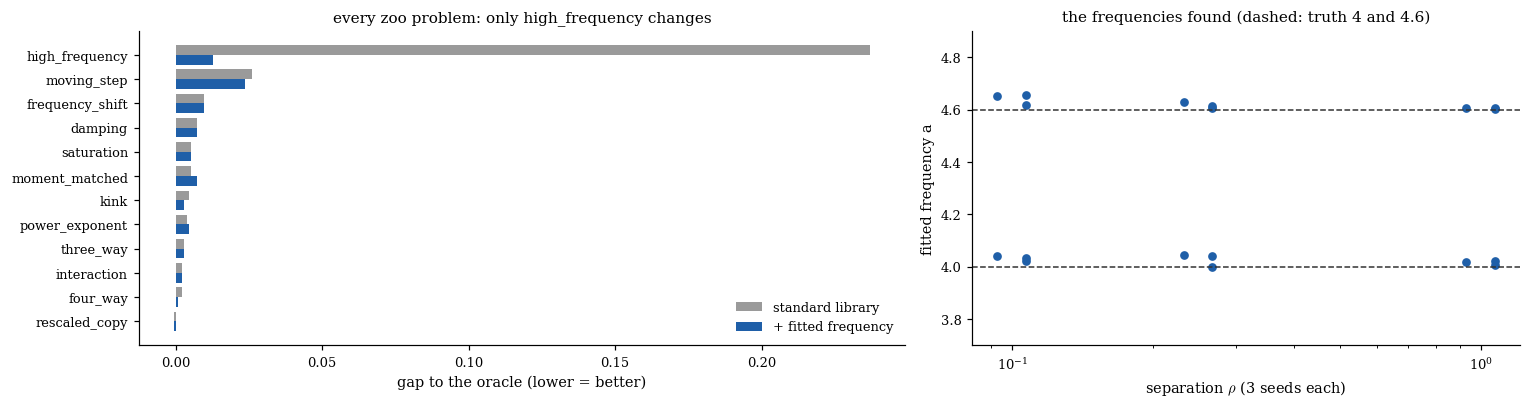

In [27]:
T = pd.read_csv(RES / "problems" / "sinusoid_trial_summary.csv").sort_values("gap_fast")
yp = np.arange(len(T))
fig, ax = plt.subplots(1, 2, figsize=(14, 3.8), gridspec_kw={"width_ratios": [1.4, 1]})
ax[0].barh(yp + 0.2, T.gap_fast, 0.4, color="#9a9a9a", label="standard library")
ax[0].barh(yp - 0.2, T.gap_fast_sin, 0.4, color=viz.PALETTE[0], label="+ fitted frequency")
ax[0].set_yticks(yp); ax[0].set_yticklabels(T.problem, fontsize=8.5)
ax[0].set(xlabel="gap to the oracle (lower = better)", title="every zoo problem: only high_frequency changes")
ax[0].legend(loc="lower right")
raw = pd.read_csv(RES / "problems" / "sinusoid_trial_raw.csv")
hf = raw[(raw.problem == "high_frequency") & (raw.backend == "fast_sin")]
for _, r in hf.iterrows():
    f = [float(v) for v in r.fitted_freqs.split()]
    ax[1].scatter([r.rho * (0.93 + 0.07 * (r.seed % 3))] * len(f), f, s=22, color=viz.PALETTE[0])
for t in (4.0, 4.6):
    ax[1].axhline(t, color="#333333", ls="--", lw=1)
ax[1].set(xscale="log", xlabel=r"separation $\rho$ (3 seeds each)", ylabel="fitted frequency a",
          title="the frequencies found (dashed: truth 4 and 4.6)", ylim=(3.7, 4.9))
fig.tight_layout()

The gap on `high_frequency` falls from 0.237 to 0.013; the other eleven
problems are unchanged (mean change -0.0002, none worse by more than 0.003);
every seed at every separation finds both frequencies to within 0.06. The
price is speed -- the fit is about 8x slower, still ~2 s per problem. The
earlier kernel basis (mission 10) roughly halved this failure without
readable laws; the fitted frequency closes it *with* them. It is a trial: not
yet the default, and not yet in `RESULTS.md`.

**And the standard methods?** On the two sine problems, every standard way to
group these windows, on the same windows (`python -m experiments.problems.sinusoid_trial --baselines`):
clustering window summaries, K-means on the raw curve, plain symbolic
regression per window -- with the library *and* with the same fitted-frequency
vocabulary, so the new term is not credited to LR-DSR -- and the
signal-processing standard for oscillations, a **periodogram** per window
(Lomb-Scargle, which allows irregular sampling), then K-means.

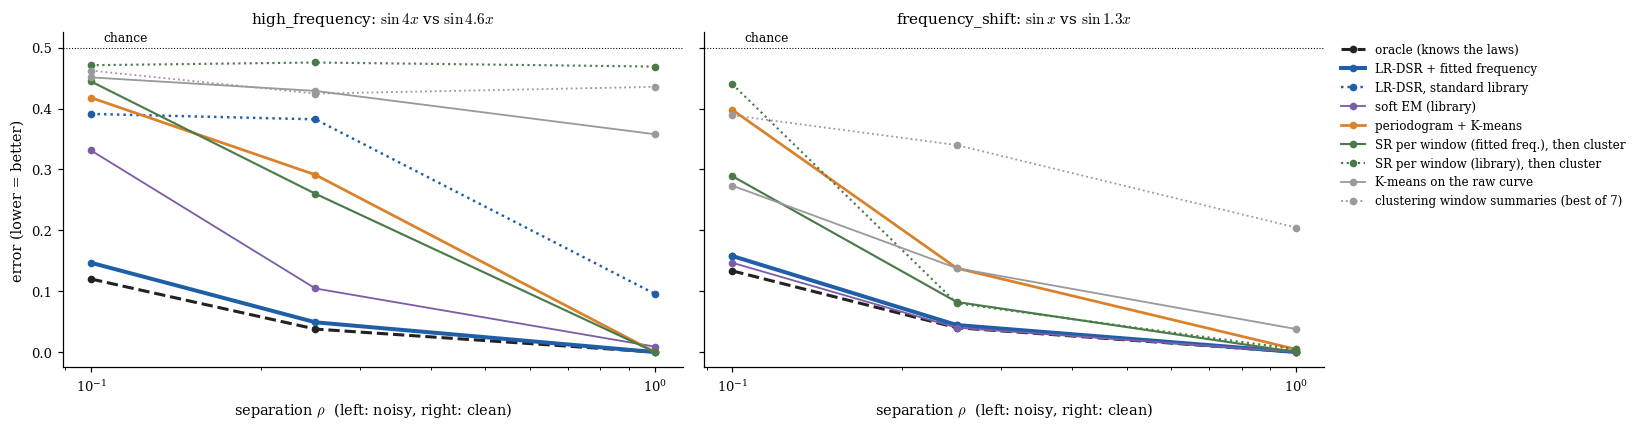

In [28]:
B = pd.read_csv(RES / "problems" / "sinusoid_baselines_raw.csv")
B = B.groupby(["problem", "rho", "method"]).error.mean().reset_index()
arms = [("oracle", "oracle (knows the laws)", "#222222", "--", 2.0),
        ("lrdsr_sin", "LR-DSR + fitted frequency", viz.PALETTE[0], "-", 2.6),
        ("lrdsr", "LR-DSR, standard library", viz.PALETTE[0], ":", 1.6),
        ("soft_em", "soft EM (library)", viz.PALETTE[3], "-", 1.2),
        ("periodogram_kmeans", "periodogram + K-means", viz.PALETTE[1], "-", 1.8),
        ("sr_per_window_sin", "SR per window (fitted freq.), then cluster", viz.PALETTE[2], "-", 1.4),
        ("sr_per_window", "SR per window (library), then cluster", viz.PALETTE[2], ":", 1.4),
        ("profile_kmeans", "K-means on the raw curve", "#9a9a9a", "-", 1.2),
        ("geometry", "clustering window summaries (best of 7)", "#9a9a9a", ":", 1.2)]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.0), sharey=True)
for a, prob_name, ttl in zip(ax, ("high_frequency", "frequency_shift"),
                             (r"high_frequency: $\sin 4x$ vs $\sin 4.6x$", r"frequency_shift: $\sin x$ vs $\sin 1.3x$")):
    g = B[B.problem == prob_name]
    for key, lab_, col, ls, lw in arms:
        h = g[g.method == key].sort_values("rho")
        a.plot(h.rho, h.error, ls, marker="o", ms=4, color=col, lw=lw, label=lab_)
    a.axhline(0.5, color="k", lw=0.7, ls=":"); a.text(0.105, 0.51, "chance", fontsize=8)
    a.set(xscale="log", xlabel=r"separation $\rho$  (left: noisy, right: clean)", title=ttl)
ax[0].set_ylabel("error (lower = better)")
ax[1].legend(fontsize=7.8, loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()

**On clean data (right end) the standard spectral methods solve it too** -- a
periodogram is at 0.000 once $\rho = 1$. **The method's edge is in noise**: at
$\rho = 0.25$ on `high_frequency` it errs at 0.049 against 0.26-0.48 for every
standard method, close to the oracle's 0.038. The reason is pooling: a
periodogram or a per-window fit has to find the frequency from one window's
48 noisy samples, while LR-DSR fits one frequency to *all* the windows of a
regime. Giving plain symbolic regression the same fitted-frequency vocabulary
helps it only on clean data -- the vocabulary is not the advantage, the
pooling is. Of four predictions declared before this comparison, three held;
the fourth (that periodograms lose by 0.1 on `frequency_shift` at *every*
separation) failed at $\rho = 1$, where they are perfect as well.

### Failure 2: against strong classifiers on 24 standard datasets

On 24 public classification datasets (UCR archive: 9 with a daily cycle, 15
"shape" datasets), classifying by law beats a plain nearest-neighbour on the
raw series most of the time, but **loses to the best tuned standard
classifier** (and to time-warping, DTW, on shapes). When every series has the
same complete inputs, a discriminative classifier on the raw values is hard to
beat; the repairs (a time-shift nuisance, a stacked head) close part of the
gap, not all.

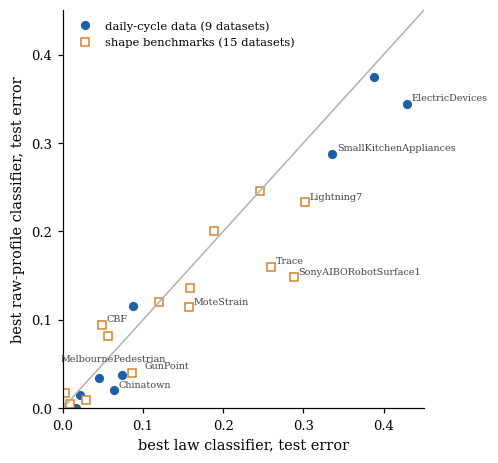

In [29]:
CF["classify_benchmark"]();

### Failure 3: noise that is correlated in time

The model is $y = f(x) + \varepsilon$, and the method assumes the **noise**
$\varepsilon$ is independent from sample to sample -- a fresh coin flip each
time. Time correlation in the *data* is fine: a daily curve that rises and
falls smoothly is the law $f$ itself. But real noise often *wanders*: once a
day runs above its curve it tends to stay above for a while. Wandering noise
carries less information per sample, and the method -- which sums samples as
if each were new evidence -- does not know that.

This check (`python -m experiments robustness`) keeps the twelve zoo problems,
their laws and their noise level exactly, and changes only one thing: the
noise becomes an AR(1) process with lag-1 correlation $\phi$. Left: what that
looks like.

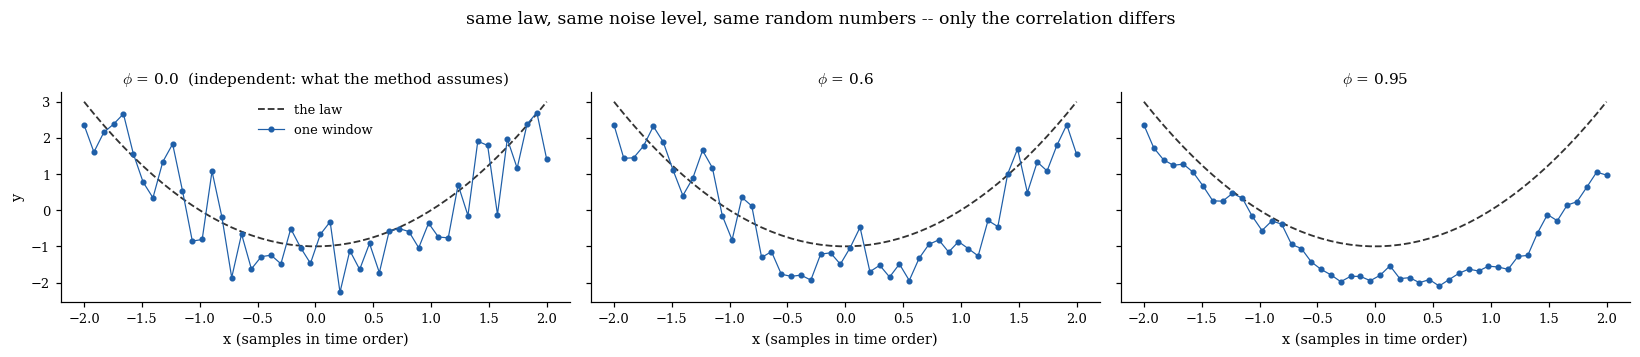

In [30]:
from experiments.robustness.run import ar1
from analysis.figs_robustness import FIGURES as RB

rng = np.random.default_rng(5)
xs = np.linspace(-2, 2, 48); u = rng.normal(size=48)
fig, ax = plt.subplots(1, 3, figsize=(15, 3.1), sharey=True)
for a, phi in zip(ax, (0.0, 0.6, 0.95)):
    a.plot(xs, xs**2 - 1, "--", color="#333333", lw=1.2, label="the law")
    a.plot(xs, xs**2 - 1 + 0.8 * ar1(u, phi), "o-", ms=3, lw=0.8, color=viz.PALETTE[0], label="one window")
    a.set(title=rf"$\phi$ = {phi}" + ("  (independent: what the method assumes)" if phi == 0 else ""),
          xlabel="x (samples in time order)")
ax[0].set_ylabel("y"); ax[0].legend(loc="upper center")
fig.suptitle("same law, same noise level, same random numbers -- only the correlation differs", y=1.03)
fig.tight_layout()

**The failure in one picture.** As the correlation grows, the method falls
further behind the oracle -- from 2 points with independent noise to 19 at
$\phi = 0.95$. The green band is how correlated the residuals of the real days
are: there the extra cost is about one point.

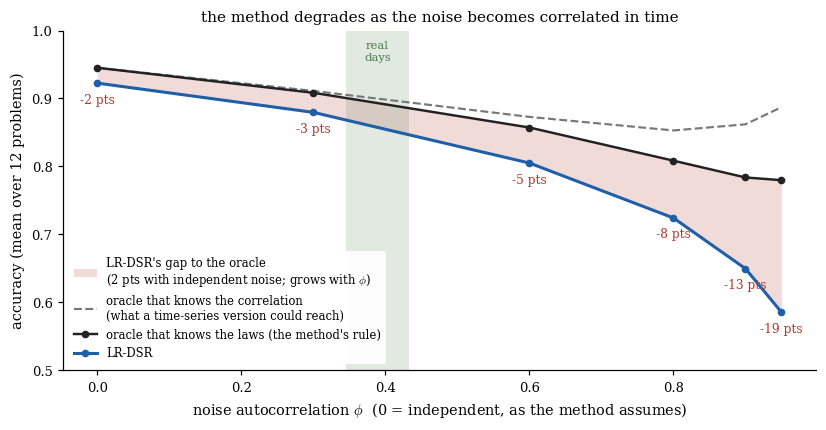

In [31]:
RB["robustness_failure"]();

In more detail. **(a)** Every method gets worse as $\phi$ grows -- including the
oracle that knows the laws but sums samples (solid black), because correlated
samples are fewer *effective* samples. The method's extra loss on top of that
stays small up to $\phi \approx 0.3$ (0.029 vs 0.023 with independent noise) but
grows beyond (0.084 at $\phi = 0.8$): the start in mechanism space assumes round
noise clouds, and correlated noise makes them elongated. **(b)** The error is
still an exact formula, for both rules. **(c)** An oracle that *knows* the
correlation (dashed in (a)) whitens it away and even gets **better** at very
high $\phi$: smooth noise is easy to separate from a law gap that changes
quickly (a moving step, an interaction). **(d)** On the real bike and traffic
days the residual correlation is moderate (lag 1: 0.35 and 0.43) and dies out
after one hour -- shorter memory than AR(1) -- so real days sit in the green
band of (a), where the cost is small.

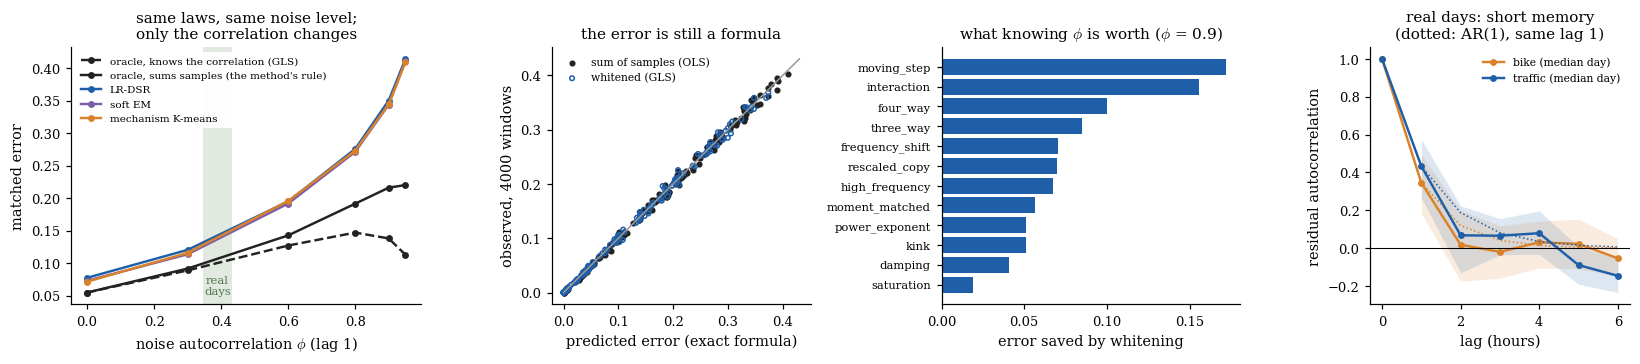

In [32]:
RB["robustness_ar_noise"]();

**Verdict: partly robust.** On data like the real days the independence
assumption costs little; with strongly wandering noise ($\phi \ge 0.6$) the
method loses clearly more than its own rule does, and a time-series version
(whitening the residuals inside the loop, with $\phi$ estimated from them) is
the natural fix -- the dashed curve shows how much it could gain. Of the five
predictions declared before the run, two held (the exact formulas at $\phi = 0$;
knowing $\phi$ helps more as it grows, though mostly on `moving_step` rather
than `high_frequency`) and three failed: the formula band was set tighter
than the Monte-Carlo noise of 150 windows (at 4000 windows every cell is
within 3 standard errors -- a check added after the run), the method's extra
loss passes 0.05 at $\phi = 0.6$, and the real residual correlation is below the
predicted 0.5.

### The other negatives (kept, not hidden)

* Choosing the number of laws $K$ by BIC fails on real days (it keeps adding).
* The partial-day error formula (V11) ranks which hours matter correctly, but
  its absolute level is off by a factor of a few.
* Scattered, irregular sampling gives no edge -- only *long* gaps do.
* Wind: one declared prediction failed (the wake effect), and unsupervised
  clusters of wind blocks match no physical proxy.

---
# 7 · Every task in one picture

Fifteen missions and the new symbolic-regression baseline. Each panel is the
headline comparison of one mission; the frame colour is the verdict
(**green** holds, **amber** partly). Unless the panel says otherwise, lower is
better. All numbers are read from `results/` by `analysis.report.numbers()`.

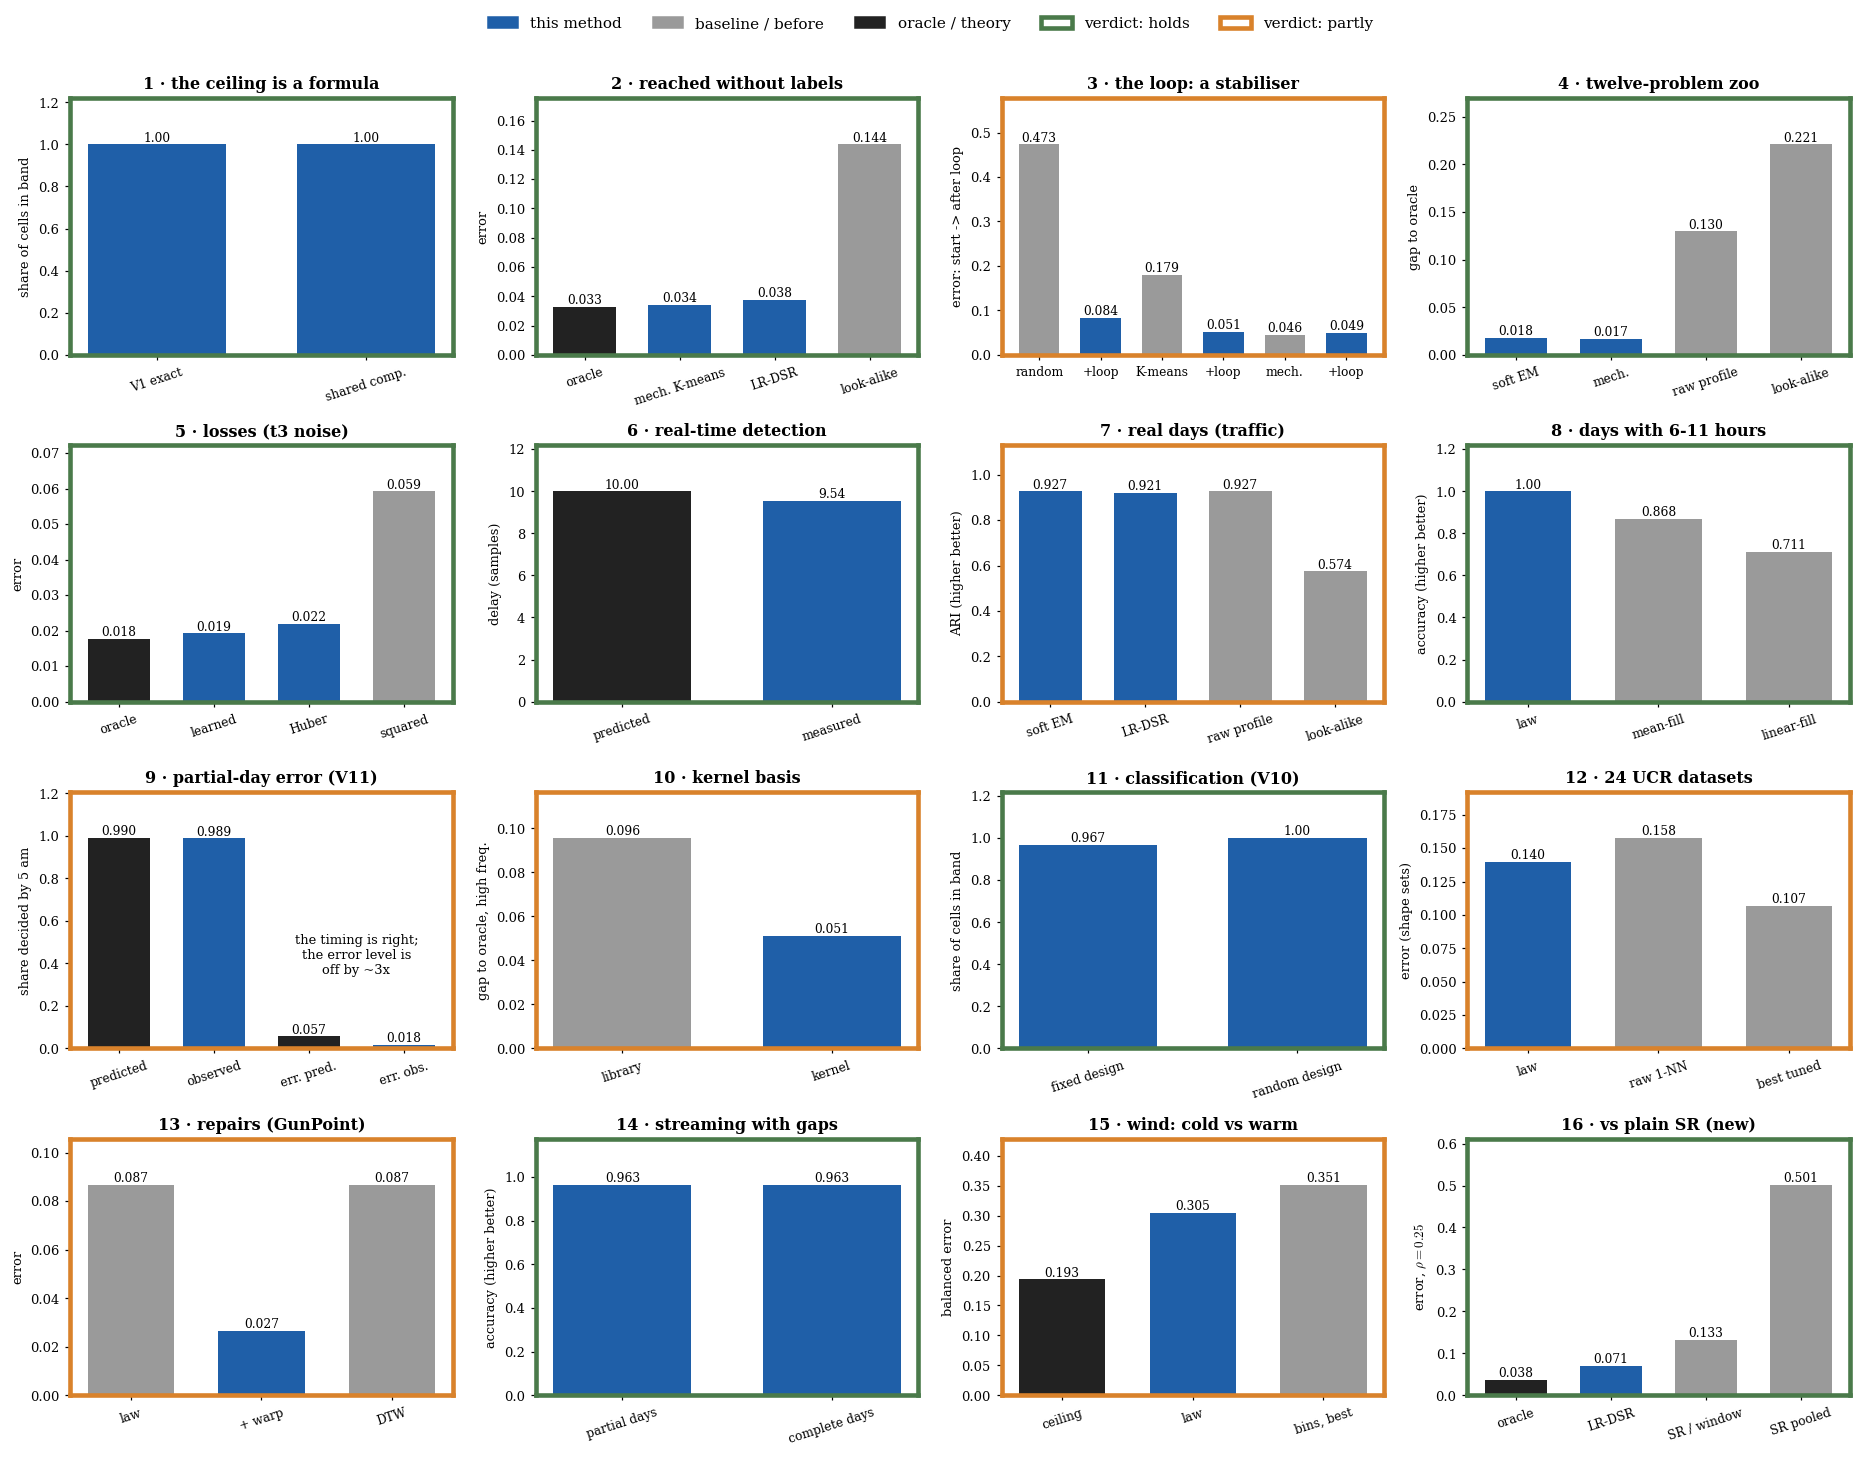

In [33]:
from analysis.report import numbers
N = numbers()
sa = pd.read_csv(RES / "srbaseline" / "estimation_assignment.csv").set_index("rho").loc[0.25]
HOLD, PART = viz.PALETTE[2], viz.PALETTE[1]
ME, BASE, REF = viz.PALETTE[0], "#9a9a9a", "#222222"

panels = [  # (title, verdict, y-label, [(bar label, value, role)])
 ("1 · the ceiling is a formula", HOLD, "share of cells in band",
  [("V1 exact", N["v1_cells"] / 18, "me"), ("shared comp.", N["v4_unchanged"] / N["v4_cells"], "me")]),
 ("2 · reached without labels", HOLD, "error",
  [("oracle", N["bench_oracle"], "ref"), ("mech. K-means", N["bench_mechanism_kmeans"], "me"),
   ("LR-DSR", N["bench_lrdsr"], "me"), ("look-alike", N["bench_window_features"], "base")]),
 ("3 · the loop: a stabiliser", PART, "error: start -> after loop",
  [("random", N["loop_random_in"], "base"), ("+loop", N["loop_random_out"], "me"),
   ("K-means", N["loop_kmeans_in"], "base"), ("+loop", N["loop_kmeans_out"], "me"),
   ("mech.", N["loop_mechanism_in"], "base"), ("+loop", N["loop_mechanism_out"], "me")]),
 ("4 · twelve-problem zoo", HOLD, "gap to oracle",
  [("soft EM", N["zoo_gap_soft_em"], "me"), ("mech.", N["zoo_gap_mechanism_kmeans"], "me"),
   ("raw profile", N["zoo_gap_profile_kmeans"], "base"), ("look-alike", N["zoo_gap_geometry"], "base")]),
 ("5 · losses (t3 noise)", HOLD, "error",
  [("oracle", N["le_student_t3_oracle_lrt"], "ref"), ("learned", N["le_student_t3_hard_learned"], "me"),
   ("Huber", N["le_student_t3_hard_huber"], "me"), ("squared", N["le_student_t3_hard_squared"], "base")]),
 ("6 · real-time detection", HOLD, "delay (samples)",
  [("predicted", N["cusum_delay_pred"], "ref"), ("measured", N["cusum_delay_learned"], "me")]),
 ("7 · real days (traffic)", PART, "ARI (higher better)",
  [("soft EM", N["rd_traffic_soft_fourier_ari"], "me"), ("LR-DSR", N["rd_traffic_lrdsr_ari"], "me"),
   ("raw profile", N["rd_traffic_profile_ari"], "base"), ("look-alike", N["rd_traffic_geom_ari"], "base")]),
 ("8 · days with 6-11 hours", HOLD, "accuracy (higher better)",
  [("law", N["gap_lo_law"], "me"), ("mean-fill", N["gap_lo_mean"], "base"), ("linear-fill", N["gap_lo_lin"], "base")]),
 ("9 · partial-day error (V11)", PART, "share decided by 5 am",
  [("predicted", N["v11_traffic_5h_pred"], "ref"), ("observed", N["v11_traffic_5h_obs"], "me"),
   ("err. pred.", N["v11_cal_mid_pred"], "ref"), ("err. obs.", N["v11_cal_mid_obs"], "me")]),
 ("10 · kernel basis", PART, "gap to oracle, high freq.",
  [("library", N["k_hf_soft_em_library"], "base"), ("kernel", N["k_hf_soft_em_kernel"], "me")]),
 ("11 · classification (V10)", HOLD, "share of cells in band",
  [("fixed design", N["v10_fixed_in"] / N["v10_cells"], "me"), ("random design", N["v10x_in"] / N["v10x_n"], "me")]),
 ("12 · 24 UCR datasets", PART, "error (shape sets)",
  [("law", N["ucr_shape_law_vs_1nn_a"], "me"), ("raw 1-NN", N["ucr_shape_law_vs_1nn_b"], "base"),
   ("best tuned", N["ucr_shape_best_b"], "base")]),
 ("13 · repairs (GunPoint)", PART, "error",
  [("law", N["rp_GunPoint_law"], "base"), ("+ warp", N["rp_GunPoint_shift"], "me"), ("DTW", N["rp_GunPoint_dtw"], "base")]),
 ("14 · streaming with gaps", HOLD, "accuracy (higher better)",
  [("partial days", N["st_partial_acc"], "me"), ("complete days", N["st_complete_acc"], "me")]),
 ("15 · wind: cold vs warm", PART, "balanced error",
  [("ceiling", N["w_cold_ceiling"], "ref"), ("law", N["w_cold_law"], "me"), ("bins, best", N["w_cold_bins_best"], "base")]),
 ("16 · vs plain SR (new)", HOLD, r"error, $\rho = 0.25$",
  [("oracle", sa.oracle_error, "ref"), ("LR-DSR", sa.lrdsr_error, "me"),
   ("SR / window", sa.sr_per_window_error, "base"), ("SR pooled", sa.sr_pooled_error, "base")]),
]
role = {"me": ME, "base": BASE, "ref": REF}
fig, axes = plt.subplots(4, 4, figsize=(17, 13))
for a, (title, verdict, ylab, bars) in zip(axes.flat, panels):
    xp = np.arange(len(bars)); vals = [b[1] for b in bars]
    a.bar(xp, vals, color=[role[b[2]] for b in bars], width=0.66)
    for i, v in enumerate(vals):
        a.text(i, v, f"{v:.3f}" if v < 1 else f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    a.set_xticks(xp); a.set_xticklabels([b[0] for b in bars], fontsize=8, rotation=18 if len(bars) < 6 else 0)
    a.set_title(title, fontsize=10.5, weight="bold"); a.set_ylabel(ylab, fontsize=8.5)
    a.set_ylim(0, max(vals) * 1.22)
    for s in a.spines.values():
        s.set_visible(True); s.set_color(verdict); s.set_linewidth(3)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=ME, label="this method"), Patch(color=BASE, label="baseline / before"),
                    Patch(color=REF, label="oracle / theory"),
                    Patch(fc="white", ec=HOLD, lw=3, label="verdict: holds"),
                    Patch(fc="white", ec=PART, lw=3, label="verdict: partly")],
           loc="upper center", ncol=5, fontsize=10, bbox_to_anchor=(0.5, 1.02))
axes.flat[8].text(2.5, 0.35, "the timing is right;\nthe error level is\noff by ~3x", ha="center", fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, 0.98))

## Take-aways

1. **Clustering by the law is a well-posed problem with a known ceiling**,
   $Q(\sqrt{n\rho}/2)$, and the method reaches it without labels: the key is
   the *start* in mechanism space; the alternating loop makes it robust and
   produces readable laws.
2. **It wins where the inputs differ from window to window** -- days with
   long sensor gaps, wind turbines at different wind speeds, a new law in a
   stream. When every window has the same complete inputs, a good raw-data
   method ties it (clustering) or beats it (tuned classifiers).
3. **It beats plain symbolic regression**: fitting a law per window is too
   noisy, one law for everything is wrong; pooling the windows of a regime is
   what makes the laws accurate.
4. **Its known limit is the library**: a law the library cannot express costs
   accuracy. For fast oscillations a term with a fitted frequency (trial)
   closes the gap (0.237 → 0.013) and keeps the laws readable.
5. **It assumes independent noise.** At the correlation real days show, that
   costs little; strongly wandering noise costs more, and whitening is the
   fix to build next.

**Where next:** notebook 01 (the API on your own data), 02 (theory and
losses), 03 (the problem zoo), 04 (real time), 05 (real days), 06 (kernels
and classification), 07 (partial days), 08 (wind); `RESULTS.md` has every
number.